<a href="https://colab.research.google.com/github/Chandrika-Saha/Machine-Learning-Algos/blob/main/HousePricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1️⃣ Mount drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# 2️⃣ Create kaggle folder in Drive (only once)
!mkdir -p /content/drive/MyDrive/.kaggle

# 3️⃣ Upload kaggle.json manually to:
# /content/drive/MyDrive/.kaggle/kaggle.json

Mounted at /content/drive


In [2]:
# from google.colab import files
# files.upload()   # upload kaggle.json

In [3]:
!mkdir -p /content/drive/MyDrive/.kaggle
!mv kaggle.json /content/drive/MyDrive/.kaggle/kaggle.json

mv: cannot stat 'kaggle.json': No such file or directory


In [4]:
!ls -la /content/drive/MyDrive/.kaggle

total 1
-rw------- 1 root root 68 Feb 22 18:49 kaggle.json


In [5]:
!kaggle -v
!kaggle datasets list -s housing --max-size 1000000

Kaggle API 1.7.4.5
Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 4, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.12/dist-packages/kaggle/__init__.py", line 6, in <module>
    api.authenticate()
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 434, in authenticate
    raise IOError('Could not find {}. Make sure it\'s located in'
OSError: Could not find kaggle.json. Make sure it's located in /root/.config/kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/


In [6]:
# 3️⃣ Download dataset ONLY if not already downloaded
import os

if not os.path.exists("/content/drive/MyDrive/new-york-housing-market"):
    !kaggle datasets download -d nelgiriyewithana/new-york-housing-market -p /content/drive/MyDrive/
    !unzip /content/drive/MyDrive/new-york-housing-market.zip -d /content/drive/MyDrive/new-york-housing-market


In [7]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
filepath = "/content/drive/MyDrive/new-york-housing-market/NY-House-Dataset.csv"
df = pd.read_csv(filepath)
df.head()

,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
0,Brokered by Douglas Elliman -111 Fifth Ave,Condo for sale,315000,2,2.000000,1400.0,2 E 55th St Unit 803,"New York, NY 10022","2 E 55th St Unit 803New York, NY 10022",New York County,New York,Manhattan,East 55th Street,Regis Residence,"Regis Residence, 2 E 55th St #803, New York, N...",40.761255,-73.974483
1,Brokered by Serhant,Condo for sale,195000000,7,10.000000,17545.0,Central Park Tower Penthouse-217 W 57th New Yo...,"New York, NY 10019",Central Park Tower Penthouse-217 W 57th New Yo...,United States,New York,New York County,New York,West 57th Street,"217 W 57th St, New York, NY 10019, USA",40.766393,-73.980991
2,Brokered by Sowae Corp,House for sale,260000,4,2.000000,2015.0,620 Sinclair Ave,"Staten Island, NY 10312","620 Sinclair AveStaten Island, NY 10312",United States,New York,Richmond County,Staten Island,Sinclair Avenue,"620 Sinclair Ave, Staten Island, NY 10312, USA",40.541805,-74.196109
3,Brokered by COMPASS,Condo for sale,69000,3,1.000000,445.0,2 E 55th St Unit 908W33,"Manhattan, NY 10022","2 E 55th St Unit 908W33Manhattan, NY 10022",United States,New York,New York County,New York,East 55th Street,"2 E 55th St, New York, NY 10022, USA",40.761398,-73.974613
4,Brokered by Sotheby's International Realty - E...,Townhouse for sale,55000000,7,2.373861,14175.0,5 E 64th St,"New York, NY 10065","5 E 64th StNew York, NY 10065",United States,New York,New York County,New York,East 64th Street,"5 E 64th St, New York, NY 10065, USA",40.767224,-73.969856


In [9]:
df.shape

(4801, 17)

In [10]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4801 entries, 0 to 4800
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   BROKERTITLE                  4801 non-null   object 
 1   TYPE                         4801 non-null   object 
 2   PRICE                        4801 non-null   int64  
 3   BEDS                         4801 non-null   int64  
 4   BATH                         4801 non-null   float64
 5   PROPERTYSQFT                 4801 non-null   float64
 6   ADDRESS                      4801 non-null   object 
 7   STATE                        4801 non-null   object 
 8   MAIN_ADDRESS                 4801 non-null   object 
 9   ADMINISTRATIVE_AREA_LEVEL_2  4801 non-null   object 
 10  LOCALITY                     4801 non-null   object 
 11  SUBLOCALITY                  4801 non-null   object 
 12  STREET_NAME                  4801 non-null   object 
 13  LONG_NAME         

None

In [11]:
df.describe(include='object')

,BROKERTITLE,TYPE,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS
count,4801,4801,4801,4801,4801,4801,4801,4801,4801,4801,4801
unique,1036,13,4582,308,4583,29,11,21,174,2731,4550
top,Brokered by COMPASS,Co-op for sale,856 Washington Ave Apt 6C,"Brooklyn, NY 11235","856 Washington Ave Apt 6CBrooklyn, NY 11238",United States,New York,New York,Manhattan,2,"61-20 Grand Central Pkwy, Forest Hills, NY 113..."
freq,456,1450,3,102,3,2484,2505,1016,979,20,4


In [12]:
df.describe()

,PRICE,BEDS,BATH,PROPERTYSQFT,LATITUDE,LONGITUDE
count,4.801000e+03,4801.000000,4801.000000,4801.000000,4801.000000,4801.000000
mean,2.356940e+06,3.356801,2.373861,2184.207862,40.714227,-73.941601
std,3.135525e+07,2.602315,1.946962,2377.140894,0.087676,0.101082
min,2.494000e+03,1.000000,0.000000,230.000000,40.499546,-74.253033
25%,4.990000e+05,2.000000,1.000000,1200.000000,40.639375,-73.987143
50%,8.250000e+05,3.000000,2.000000,2184.207862,40.726749,-73.949189
75%,1.495000e+06,4.000000,3.000000,2184.207862,40.771923,-73.870638
max,2.147484e+09,50.000000,50.000000,65535.000000,40.912729,-73.702450


# Sanity Check

In [13]:
# Data types and duplicate rows
print("\nData types:\n", df.dtypes)
print("\nDuplicate rows:\n", df.duplicated().sum())

# Missing values
missing = df.isna().sum().sort_values(ascending=False)
print(f"Missing values: \n{missing}")

# Number of uniques values per column
nunique = df.nunique().sort_values(ascending=False)
print(f"\nCardinality :\n{nunique}")


Data types:
 BROKERTITLE                     object
TYPE                            object
PRICE                            int64
BEDS                             int64
BATH                           float64
PROPERTYSQFT                   float64
ADDRESS                         object
STATE                           object
MAIN_ADDRESS                    object
ADMINISTRATIVE_AREA_LEVEL_2     object
LOCALITY                        object
SUBLOCALITY                     object
STREET_NAME                     object
LONG_NAME                       object
FORMATTED_ADDRESS               object
LATITUDE                       float64
LONGITUDE                      float64
dtype: object

Duplicate rows:
 214
Missing values: 
BROKERTITLE                    0
TYPE                           0
PRICE                          0
BEDS                           0
BATH                           0
PROPERTYSQFT                   0
ADDRESS                        0
STATE                          0
MAIN_A

# Identify column groups

In [14]:
TARGET = "PRICE"

num_cols = df.select_dtypes(include=[np.number]).columns.to_list()
print(f"Numeric colums: {num_cols}\n")

cat_cols = df.select_dtypes(include=['object']).columns.to_list()
print(f"Categorical columns: {cat_cols}\n")

if TARGET in num_cols:
  num_cols.remove(TARGET)
else:
  cat_cols.remove(TARGET)

print(f"\nTarget Column: {TARGET}")

Numeric colums: ['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT', 'LATITUDE', 'LONGITUDE']

Categorical columns: ['BROKERTITLE', 'TYPE', 'ADDRESS', 'STATE', 'MAIN_ADDRESS', 'ADMINISTRATIVE_AREA_LEVEL_2', 'LOCALITY', 'SUBLOCALITY', 'STREET_NAME', 'LONG_NAME', 'FORMATTED_ADDRESS']


Target Column: PRICE


# Univariate Analysis

In [15]:
def hist_plot(s, title, bins=50, log=False):

  s = s.dropna()

  plt.figure()

  s = np.log1p(s) if log else s
  title = title + " log1p" if log else title

  plt.title(title)
  plt.hist(s, bins)
  plt.xlabel(s.name)
  plt.ylabel("Count")
  plt.show()


def box_plot(s, title):

  s = s.dropna()

  plt.figure()
  plt.boxplot(s)
  plt.title(title)
  plt.xlabel(s.name)
  plt.show()




Price summary:
 count    4.801000e+03
mean     2.356940e+06
std      3.135525e+07
min      2.494000e+03
25%      4.990000e+05
50%      8.250000e+05
75%      1.495000e+06
max      2.147484e+09
Name: PRICE, dtype: float64

Price skewness:
 66.80000463489985

Price skewness with log1p:
 0.8226331868556626


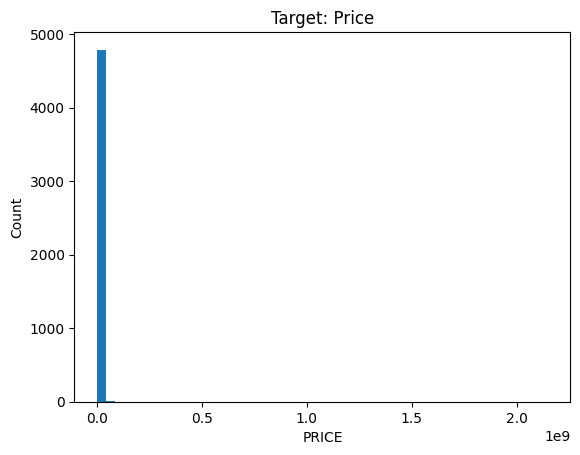

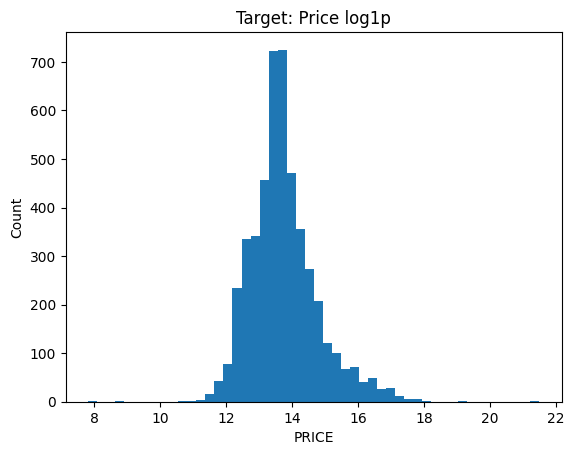

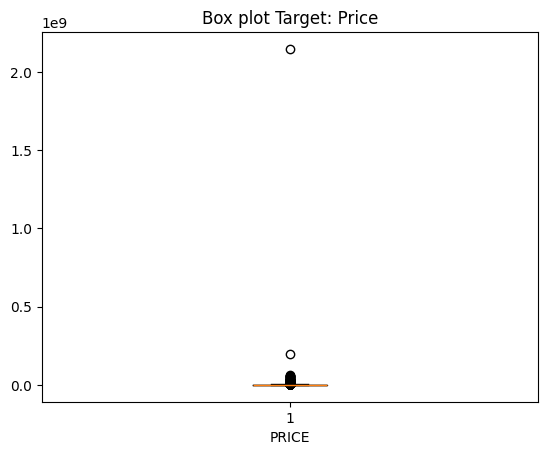

In [16]:
print("Price summary:\n", df[TARGET].describe())

print("\nPrice skewness:\n", df[TARGET].skew())

print("\nPrice skewness with log1p:\n", np.log1p(df[TARGET]).skew())

hist_plot(df[TARGET], title="Target: Price", bins=50, log=False)
hist_plot(df[TARGET], title="Target: Price", bins=50, log=True)

box_plot(df[TARGET], title="Box plot Target: Price")


BEDS summary:


,BEDS
count,4801.000000
mean,3.356801
std,2.602315
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,50.000000



BEDS skewness:


np.float64(5.449141915711713)



There are 0 negative values
  
There are 0 zeros
  
There are 4801 positive values

BEDS skewness with log1p transform:


np.float64(0.5421507870995752)

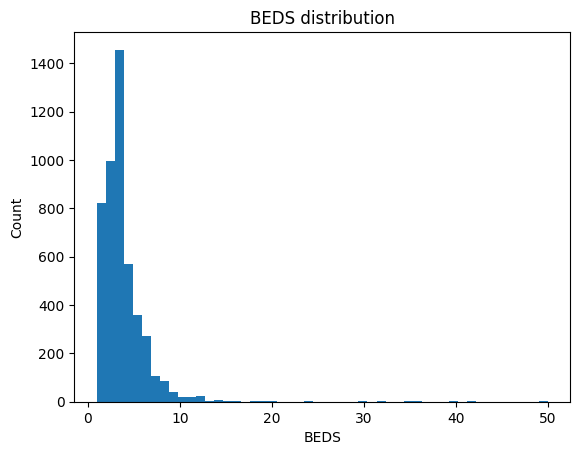

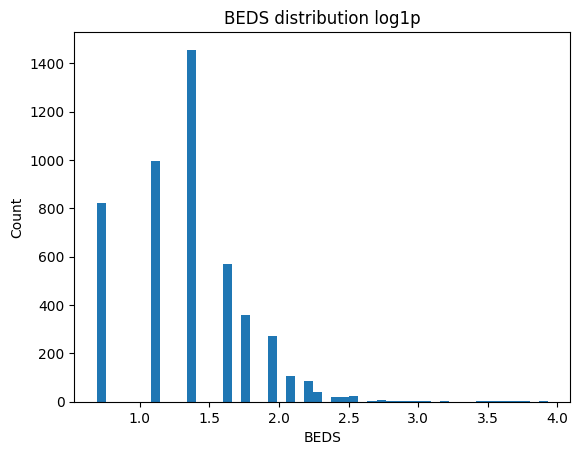


BATH summary:


,BATH
count,4801.000000
mean,2.373861
std,1.946962
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,50.000000



BATH skewness:


np.float64(7.7602199598484445)



There are 0 negative values
  
There are 3 zeros
  
There are 4798 positive values

BATH skewness with log1p transform:


np.float64(1.0070998587790665)

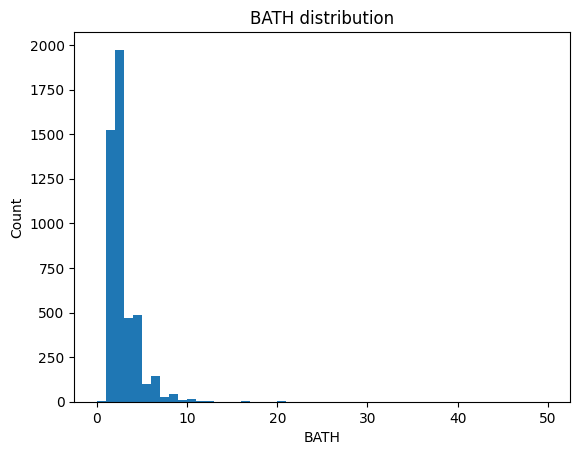

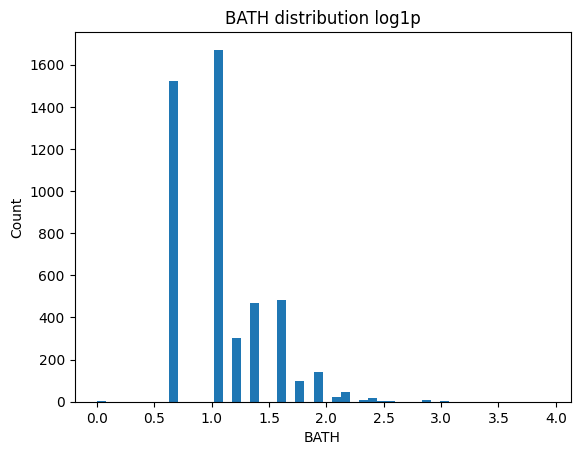


PROPERTYSQFT summary:


,PROPERTYSQFT
count,4801.000000
mean,2184.207862
std,2377.140894
min,230.000000
25%,1200.000000
50%,2184.207862
75%,2184.207862
max,65535.000000



PROPERTYSQFT skewness:


np.float64(12.800329089328672)



There are 0 negative values
  
There are 0 zeros
  
There are 4801 positive values

PROPERTYSQFT skewness with log1p transform:


np.float64(0.2889921475149606)

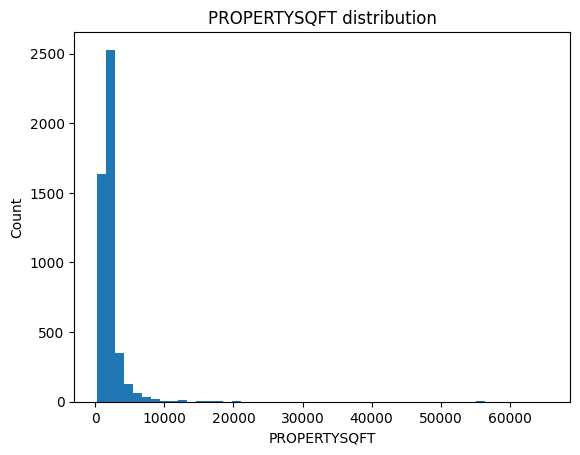

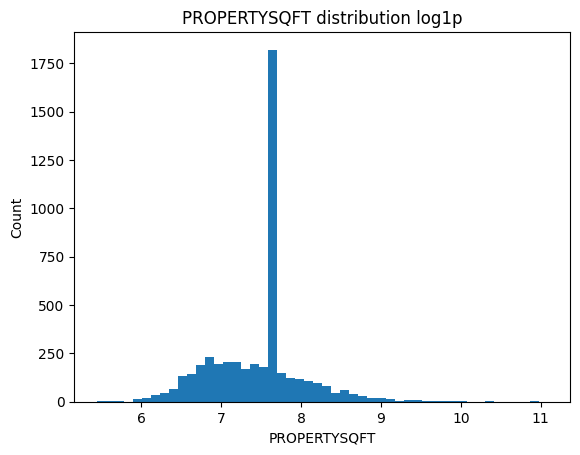


LATITUDE summary:


,LATITUDE
count,4801.000000
mean,40.714227
std,0.087676
min,40.499546
25%,40.639375
50%,40.726749
75%,40.771923
max,40.912729



LATITUDE skewness:


np.float64(-0.08840314969959585)



There are 0 negative values
  
There are 0 zeros
  
There are 4801 positive values

LATITUDE skewness with log1p transform:


np.float64(-0.09290054249958428)

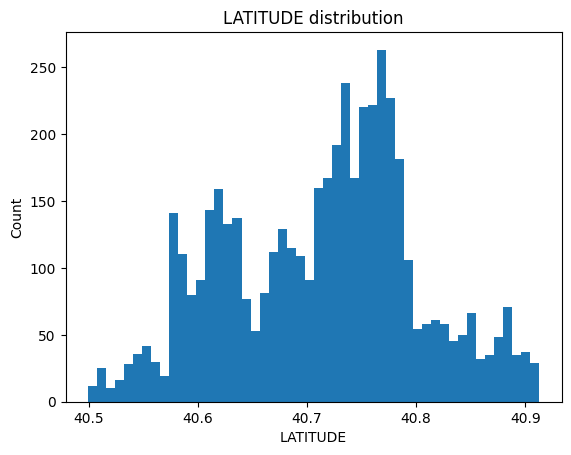

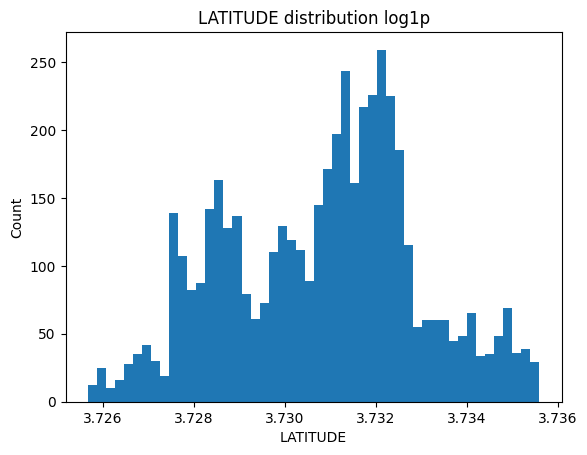


LONGITUDE summary:


,LONGITUDE
count,4801.000000
mean,-73.941601
std,0.101082
min,-74.253033
25%,-73.987143
50%,-73.949189
75%,-73.870638
max,-73.702450



LONGITUDE skewness:


np.float64(-0.3945542170632013)



There are 4801 negative values
  
There are 0 zeros
  
There are 0 positive values


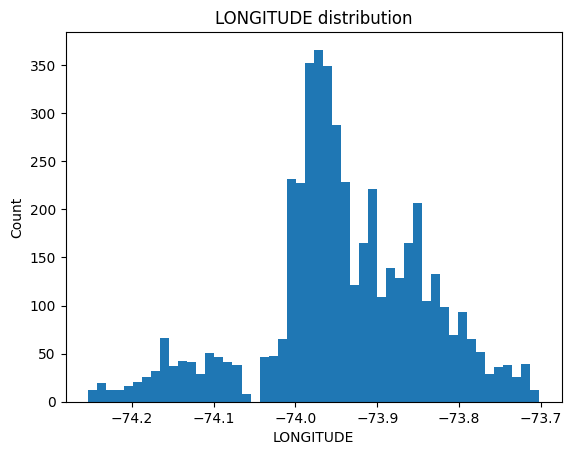

In [17]:
for col in num_cols:
  print(f"\n{col} summary:")
  display(df[col].describe())
  print(f"\n{col} skewness:")
  display(df[col].skew())
  print("\n")

  neg, zero, pos = (df[col] < 0).sum(), (df[col]==0).sum(), (df[col]>0).sum()
  print(f"""There are {neg} negative values
  \nThere are {zero} zeros
  \nThere are {pos} positive values""")

  if neg == 0:
    print(f"\n{col} skewness with log1p transform:")
    display(np.log1p(df[col]).skew())
    print("\n")

  hist_plot(df[col], f"{col} distribution", bins=50, log=False)
  if neg == 0:
    hist_plot(df[col], f"{col} distribution", bins=50, log=True)

In [18]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

def show_value_counts(df, col):
  vc = df[col].value_counts(dropna=False).head(10)
  print(f"\nValue counts for {col} is:")
  display(vc.to_frame("count"))

In [19]:
for col in cat_cols:
  show_value_counts(df, col)


Value counts for BROKERTITLE is:


,count
BROKERTITLE,
Brokered by COMPASS,456
Brokered by Douglas Elliman - 575 Madison Ave,110
Brokered by Brown Harris Stevens,93
Brokered by Corcoran East Side,91
Brokered by RE MAX Edge,79
Brokered by Winzone Realty Inc,68
Brokered by Sotheby's International Realty - East Side Manhattan Brokerage,62
Brokered by E Realty International Corp,59
Brokered by Serhant,54



Value counts for TYPE is:


,count
TYPE,
Co-op for sale,1450
House for sale,1012
Condo for sale,891
Multi-family home for sale,727
Townhouse for sale,299
Pending,243
Contingent,88
Land for sale,49
For sale,20



Value counts for ADDRESS is:


...

,count
STREET_NAME,
Manhattan,979
Brooklyn,727
Queens,684
Staten Island,480
The Bronx,310
New York,285
Flushing,139
Forest Hills,62
Bayside,42



Value counts for LONG_NAME is:


,count
LONG_NAME,
2,20
200,19
100,19
40,16
50,15
Amboy Road,15
300,13
20,12
10,12



Value counts for FORMATTED_ADDRESS is:


,count
FORMATTED_ADDRESS,
"61-20 Grand Central Pkwy, Forest Hills, NY 11375, USA",4
"856 Washington Ave #6c, Brooklyn, NY 11238, USA",3
"67-66 108th St, Forest Hills, NY 11375, USA",3
"46 Laight St, New York, NY 10013, USA",3
"120 Queens Blvd #98, Rego Park, NY 11374, USA",3
"2619 Shore Pkwy, Brooklyn, NY 11223, USA",3
"218 W 103rd St, New York, NY 10025, USA",3
"39 W 23rd St, New York, NY 10010, USA",3
"123 E 88th St #1a, New York, NY 10128, USA",2


In [20]:
# Long name column - > mix of postal code, st address
# State column -> shows the <state, postal code>, maybe not useful

# Bivariate analysis

In [21]:
def scatter_target_vs(df, x_col, y_col=TARGET, sample=4000):
  plot_df = df[[x_col, y_col]].dropna()

  plot_df = plot_df.sample(sample, random_state=42) if len(plot_df) > sample else plot_df

  plt.figure()
  plt.scatter(plot_df[x_col], plot_df[y_col], s=10)
  plt.title(f"{y_col} vs {x_col}")
  plt.xlabel(x_col)
  plt.ylabel(y_col)
  plt.show()

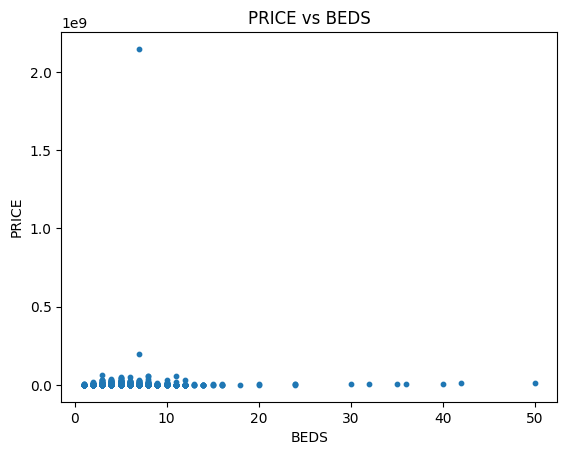

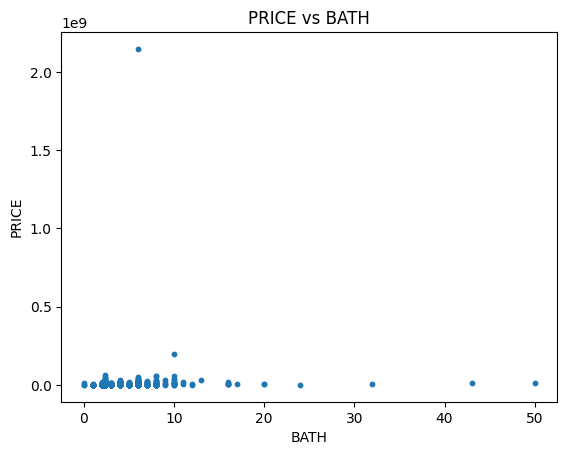

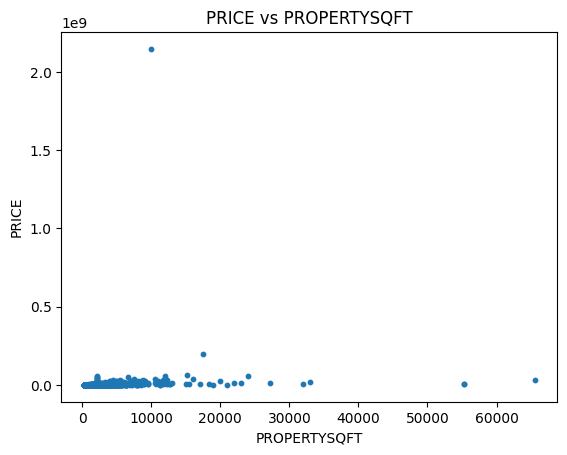

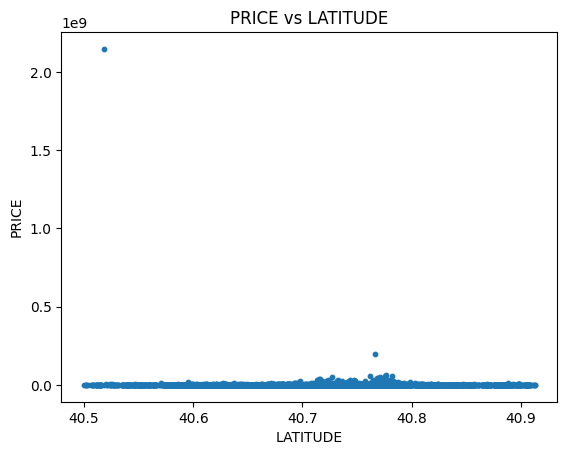

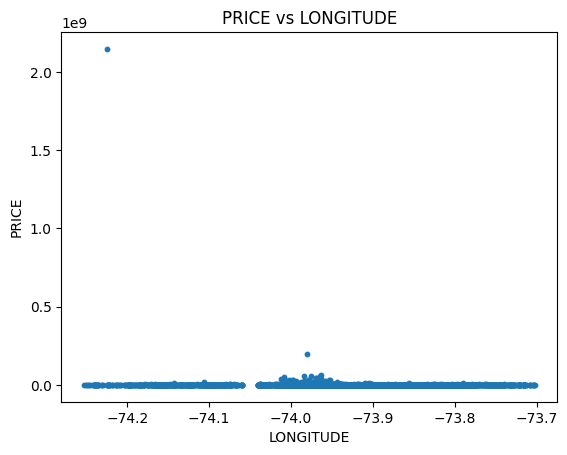

In [22]:
# scatter plots for all numeric features
for col in num_cols:
  scatter_target_vs(df, col)

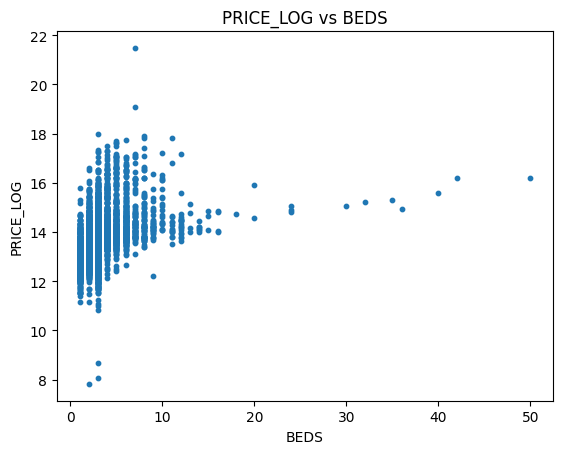

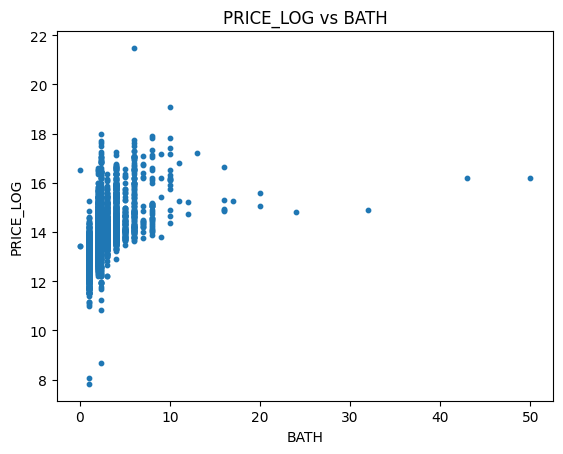

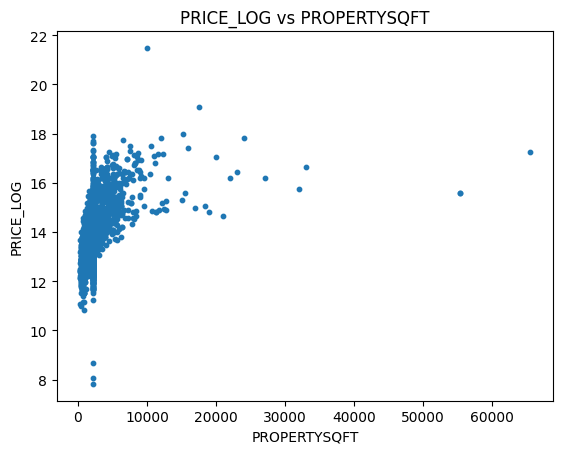

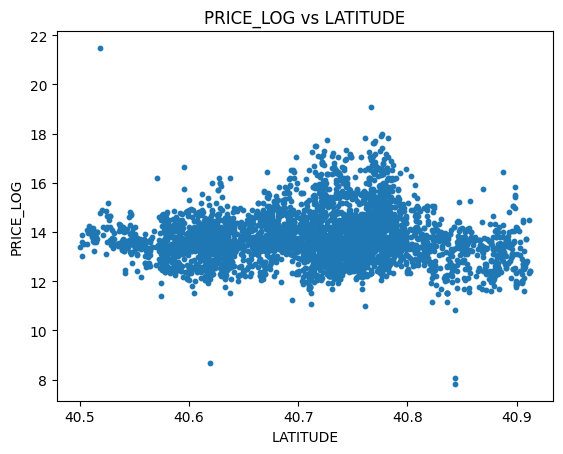

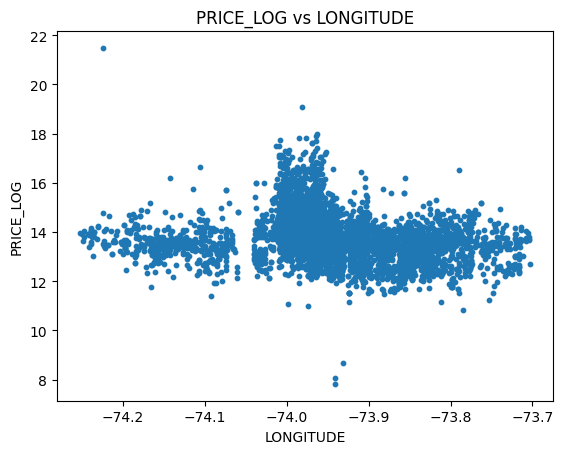

In [23]:
# Do the scatter plots for the log1p transformations too
df['PRICE_LOG'] = np.log1p(df['PRICE'])
for col in num_cols:
  scatter_target_vs(df, col, y_col='PRICE_LOG')

# Correlation map

In [24]:
def corr_map(df, corr, y_col=TARGET):
  plt.figure(figsize=(6, len(num_cols)*0.4))
  sns.heatmap(
      corr[[y_col]].sort_values(by=y_col, ascending=False),
      annot=True,
      cmap='coolwarm',
      center=0
  )
  plt.title("Correlation with Price")
  plt.show()


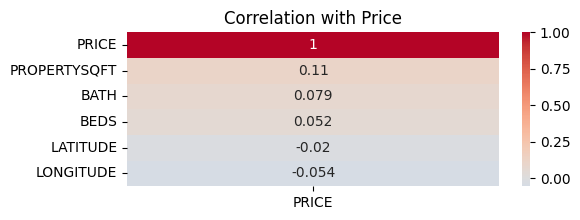

In [25]:
corr = df[[TARGET] + num_cols].corr(numeric_only=True)
corr_map(df, corr, TARGET)

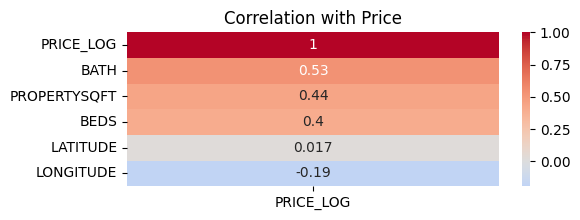

In [26]:
corr = df[['PRICE_LOG'] + num_cols].corr(numeric_only=True)
corr_map(df, corr, 'PRICE_LOG')

In [27]:
def boxplot_target_with_cat(df, cat_col, y_col=TARGET, top_k = 10, min_count=20):

  counts = df[cat_col].value_counts()
  keep = counts[counts>=min_count].head(top_k).index
  sub = df[df[cat_col].isin(keep)][[cat_col, y_col]].dropna()

  if sub.empty:
    print(f"\nSkipping {cat_col}: not enough data after filtering")
    return

  order = sub.groupby(cat_col)[y_col].median().sort_values().index.to_list()

  data = [sub[sub[cat_col] == k][y_col].values for k in order]

  plt.figure(figsize=(12, 6))
  plt.boxplot(data, label=order, vert=True)
  plt.title(f"{y_col} by {cat_col} (top {top_k}, min_count={min_count})")
  plt.ylabel(y_col)
  plt.xticks(ticks=range(1, len(order)+1), labels=order, rotation=45, ha="right")
  plt.tight_layout()
  plt.show()



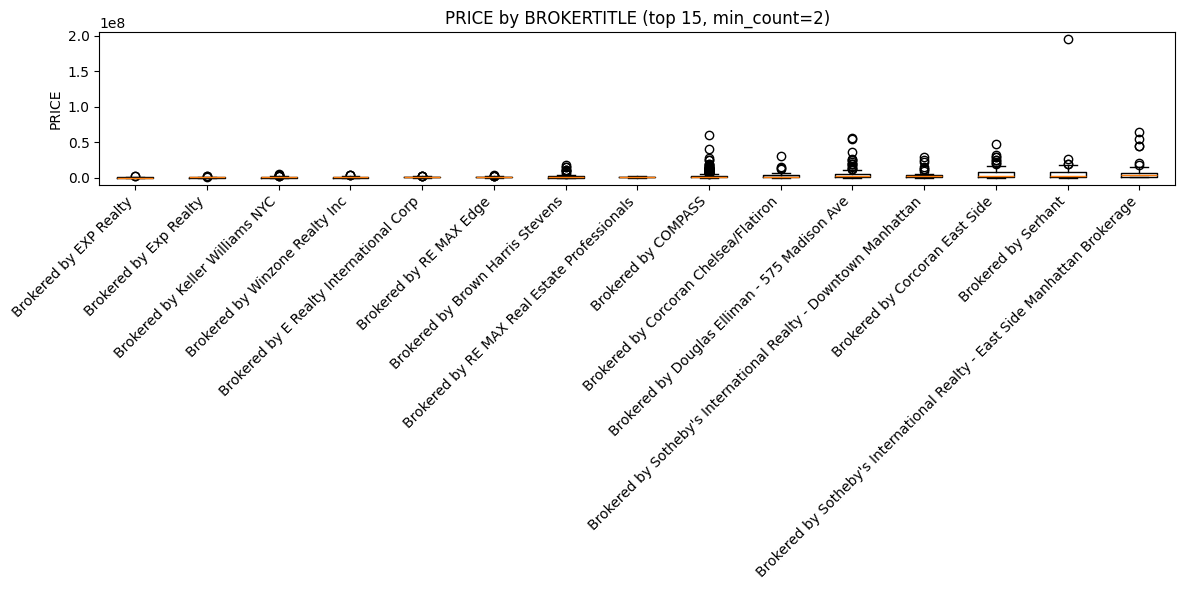

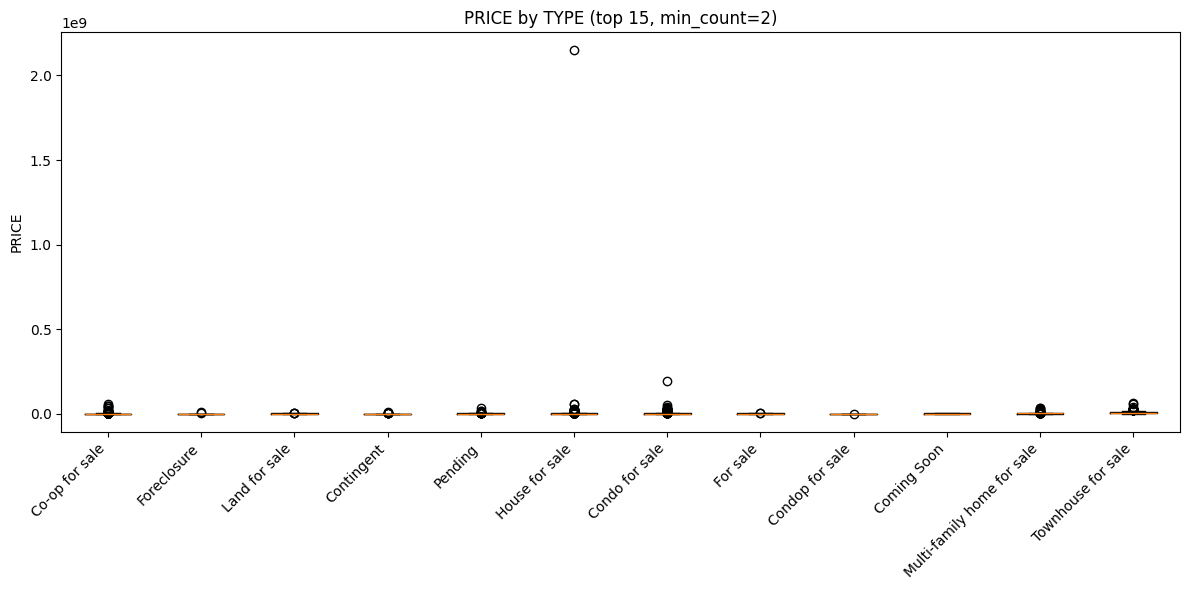

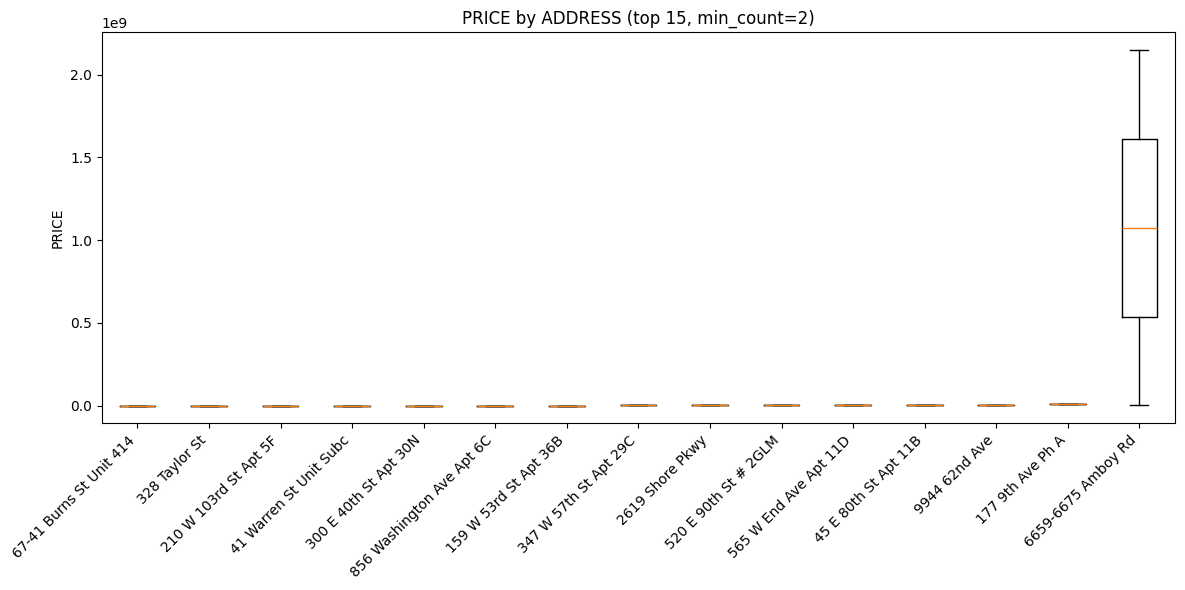

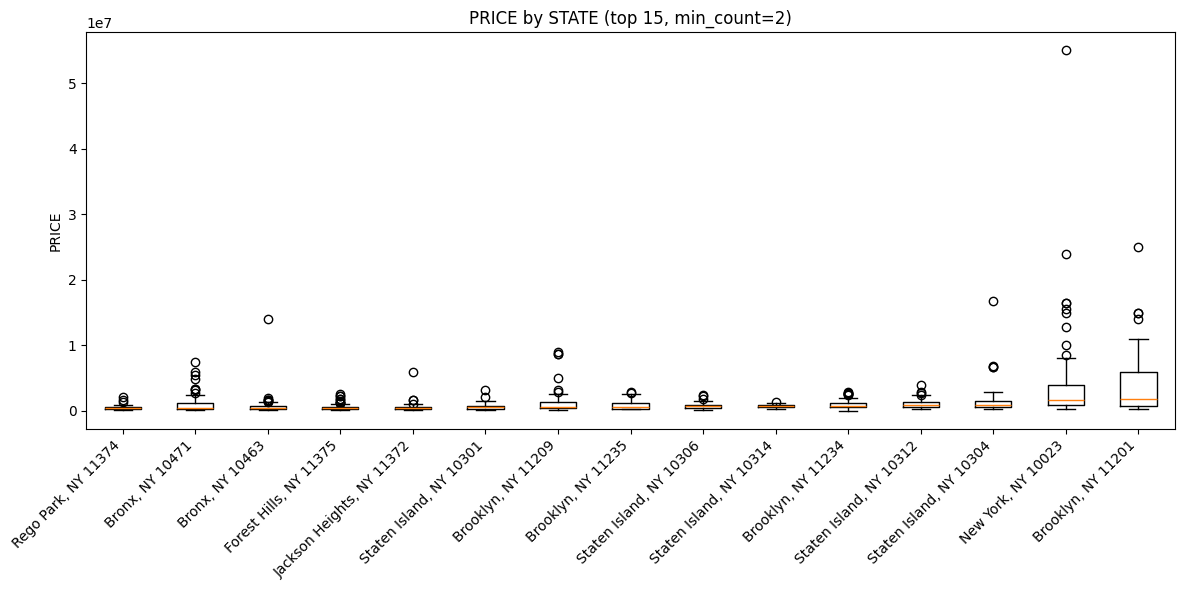

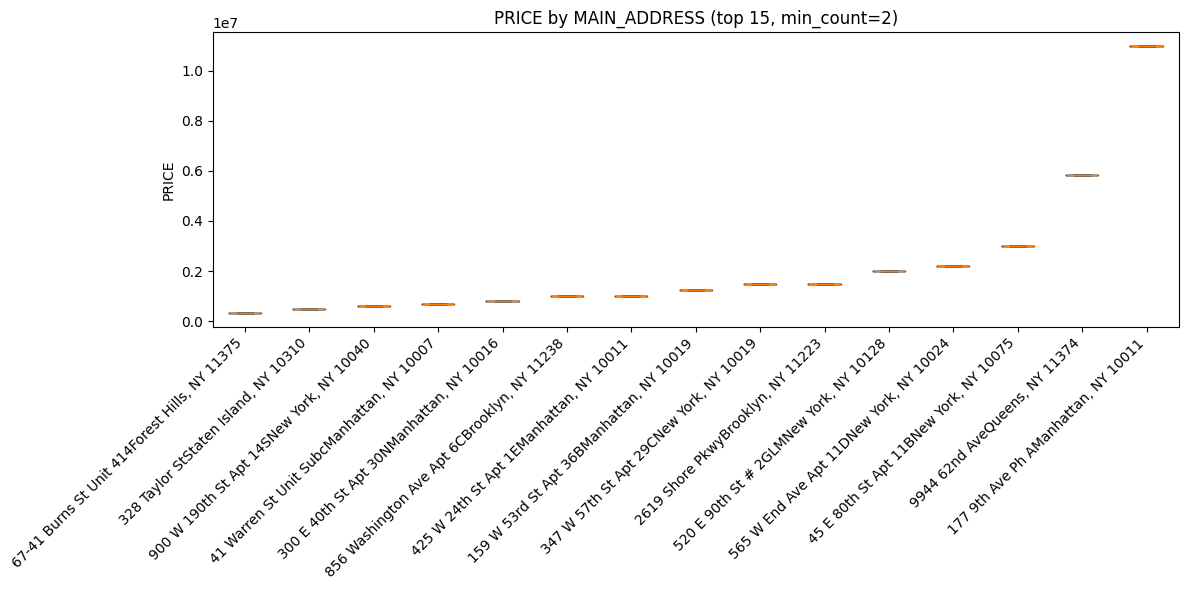

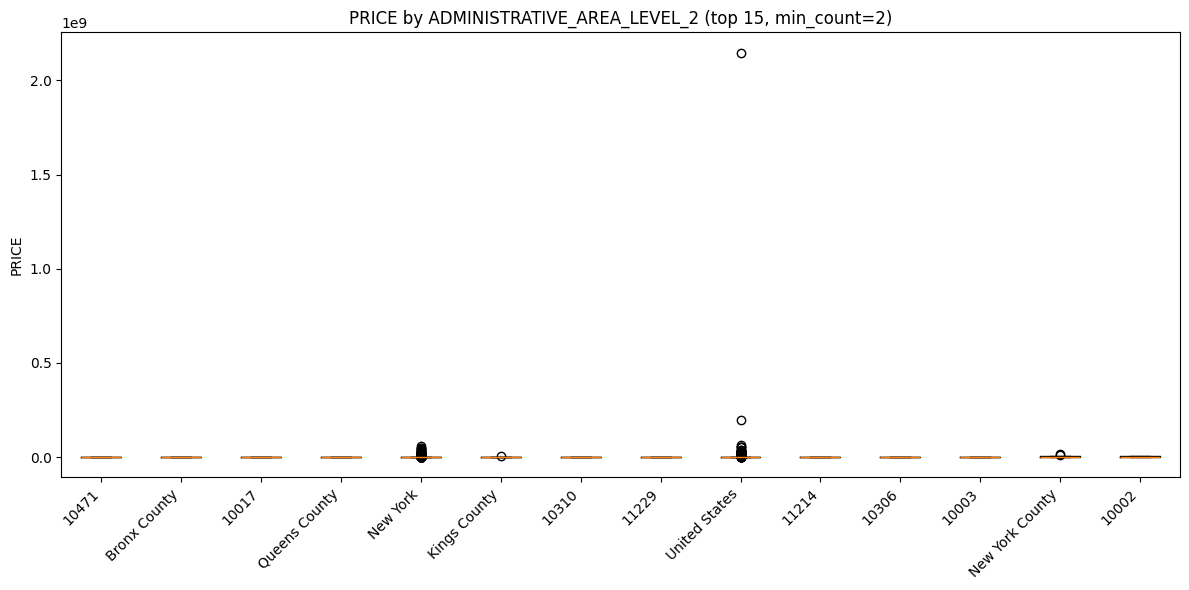

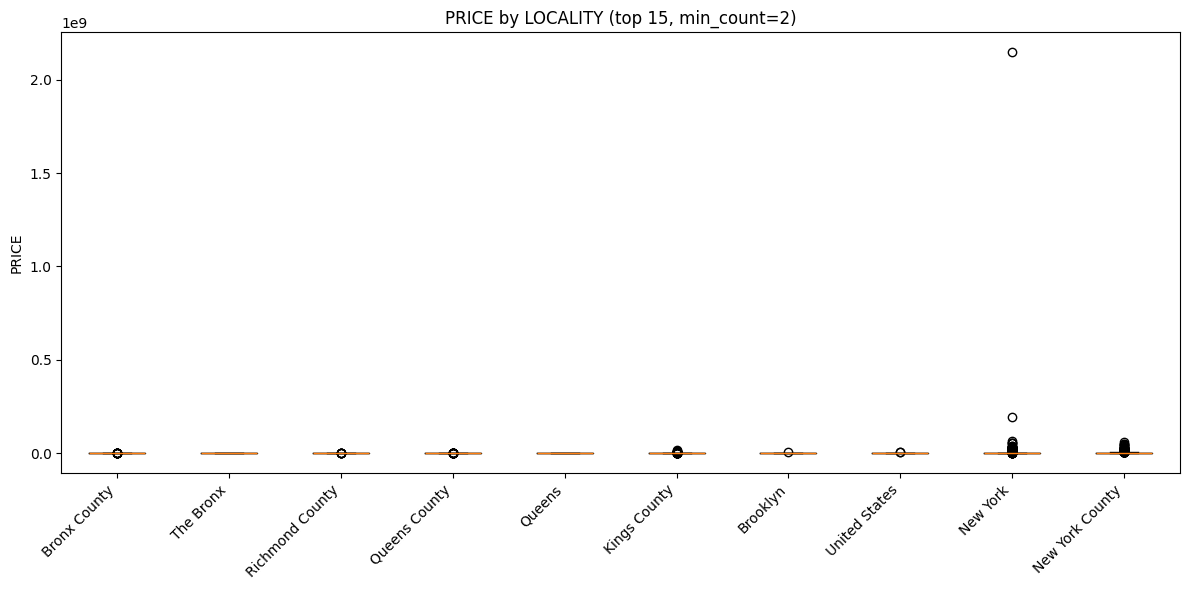

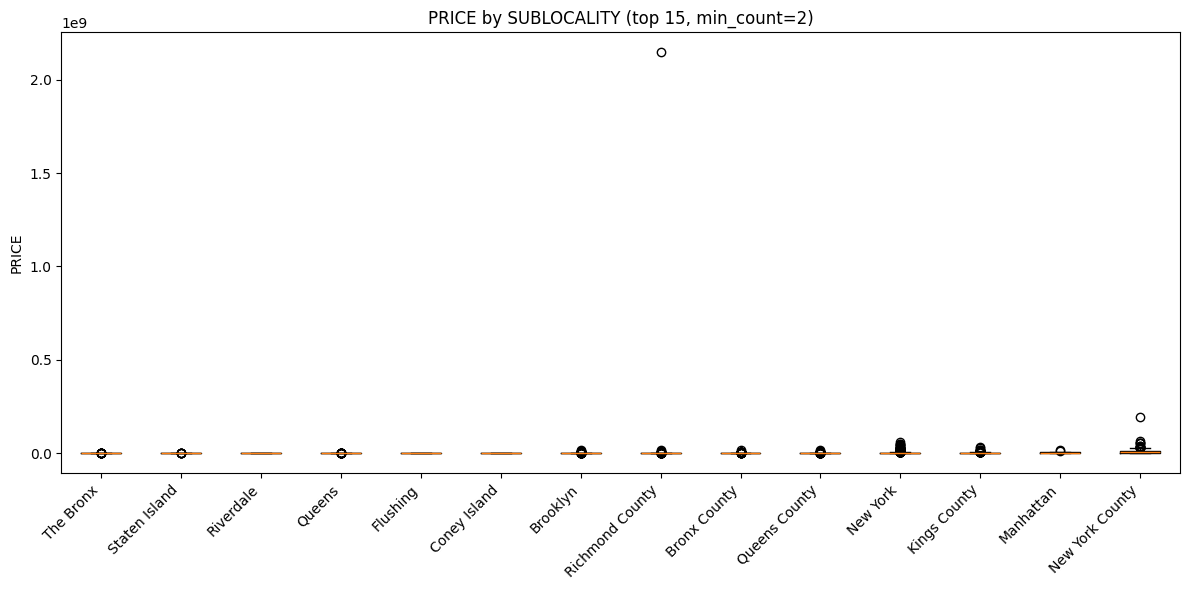

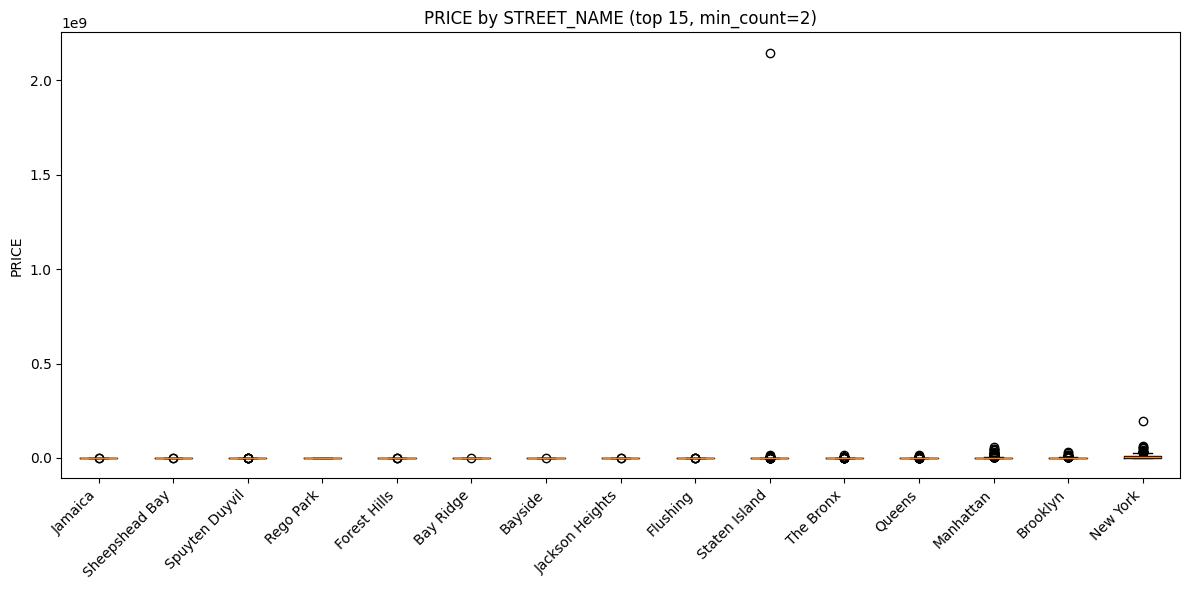

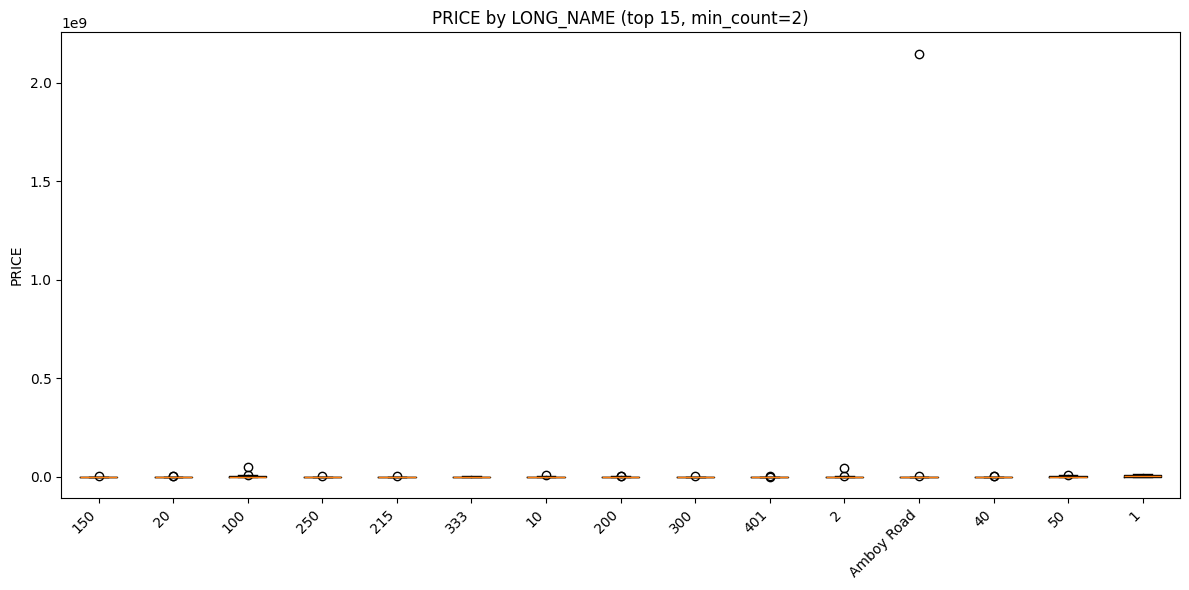

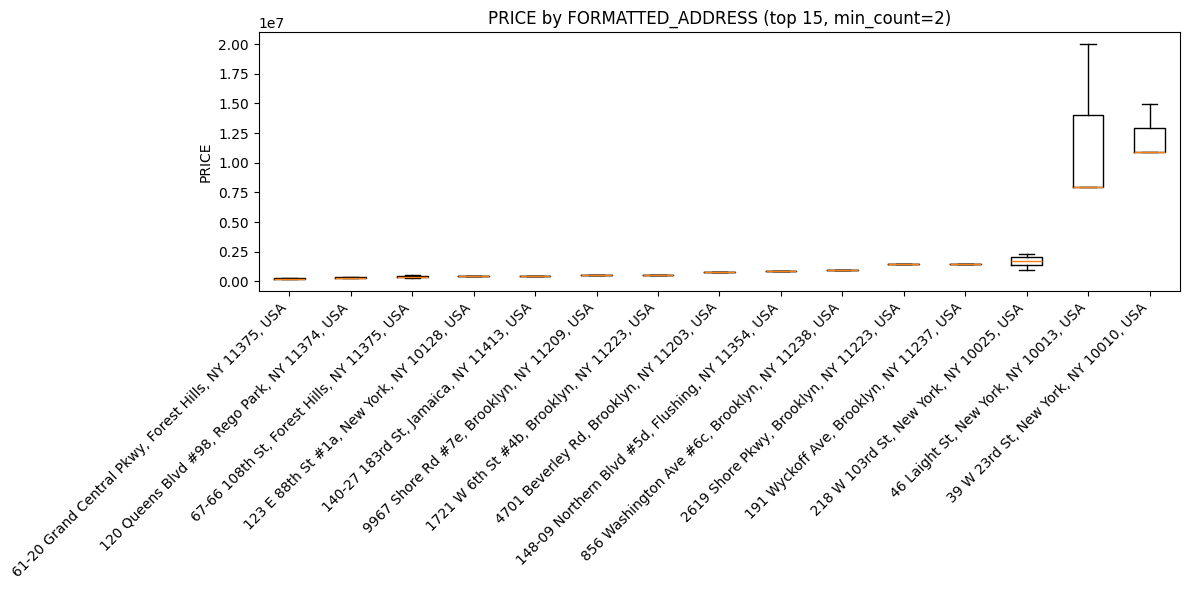

In [28]:
for col in cat_cols:
  boxplot_target_with_cat(df, col, top_k=15, min_count=2)

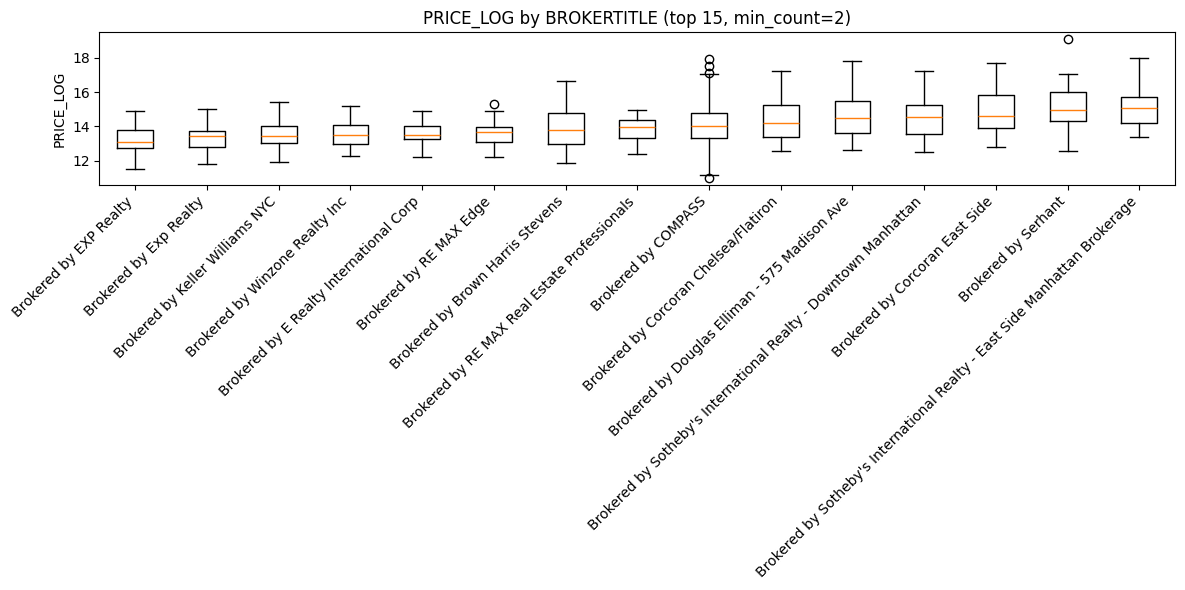

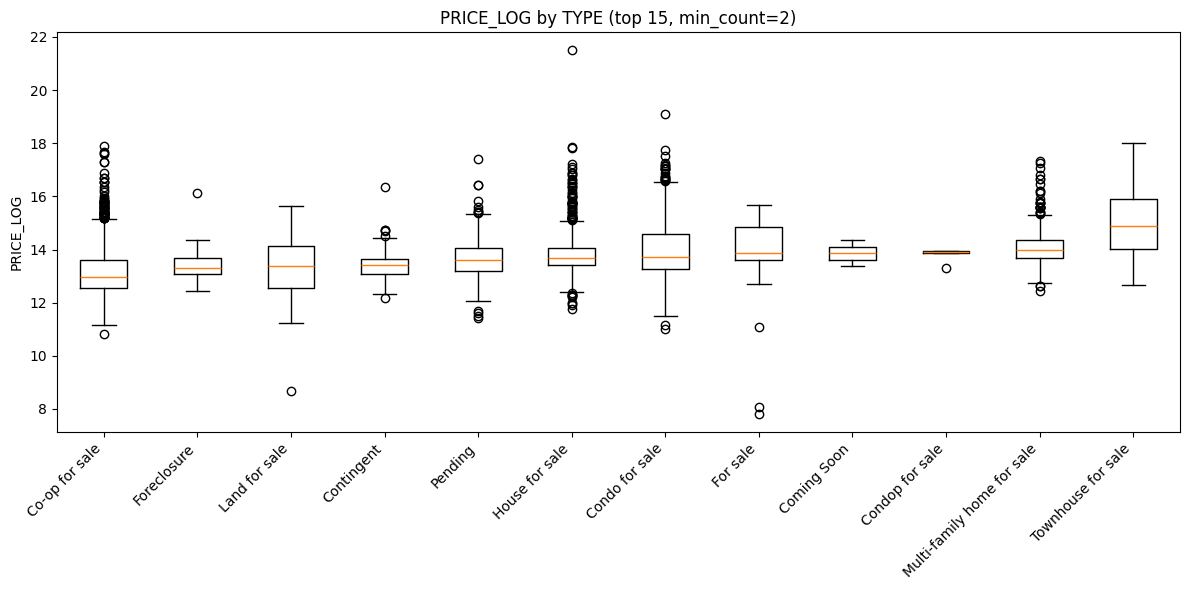

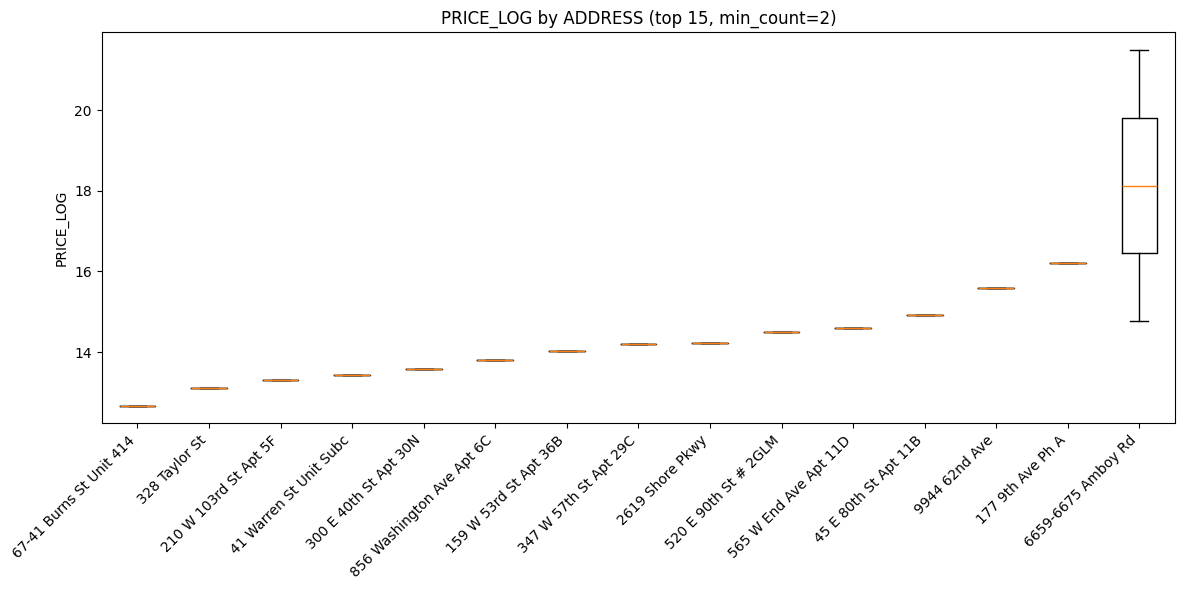

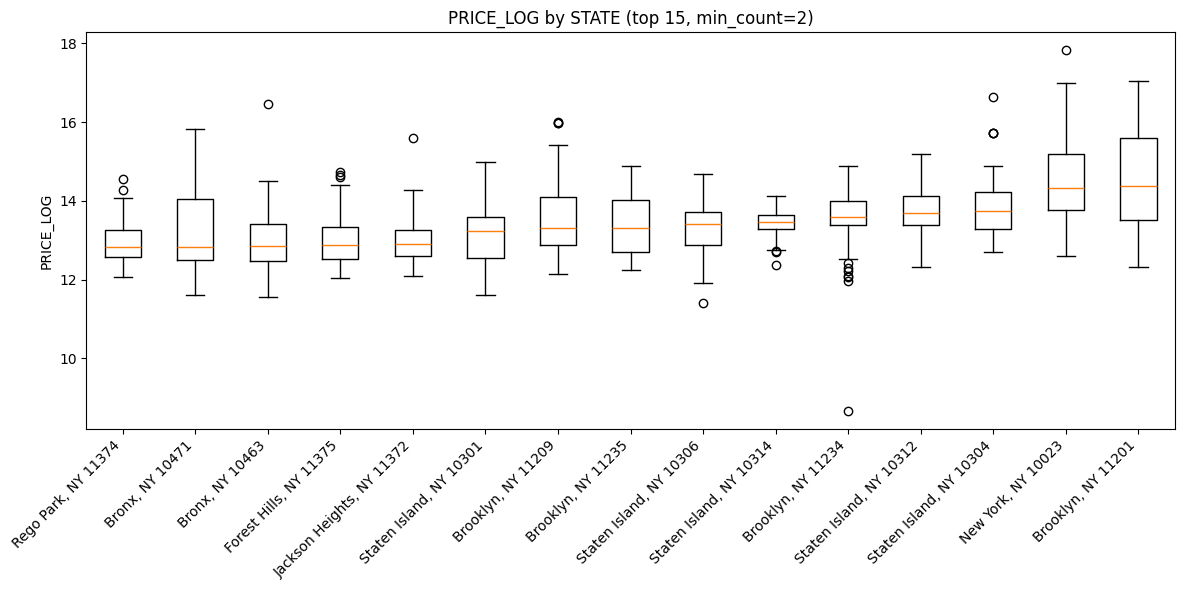

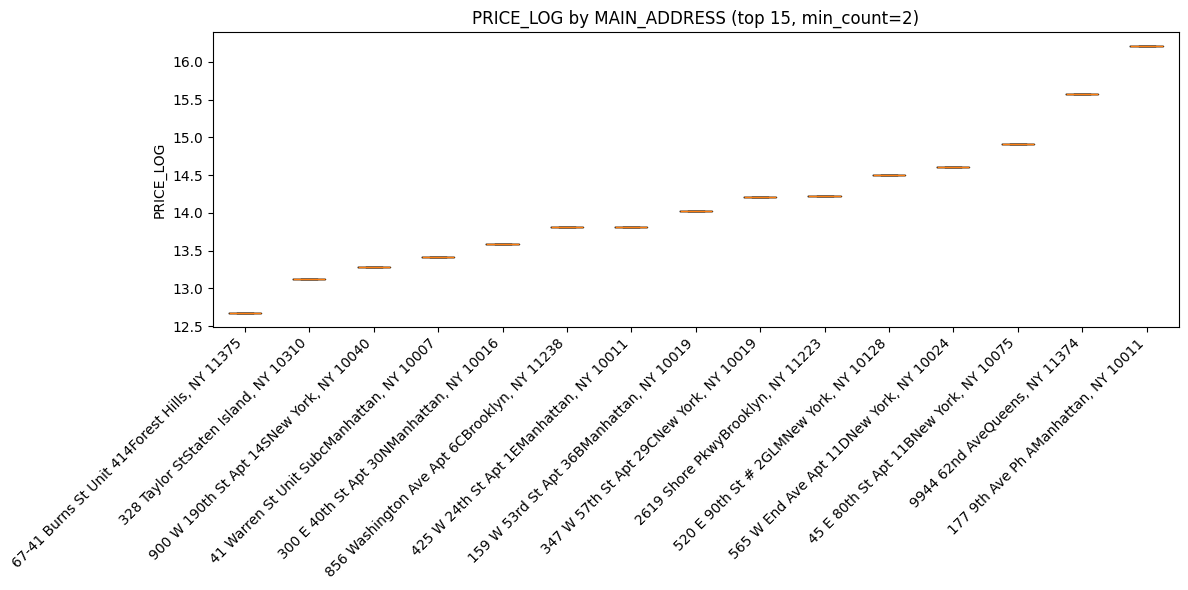

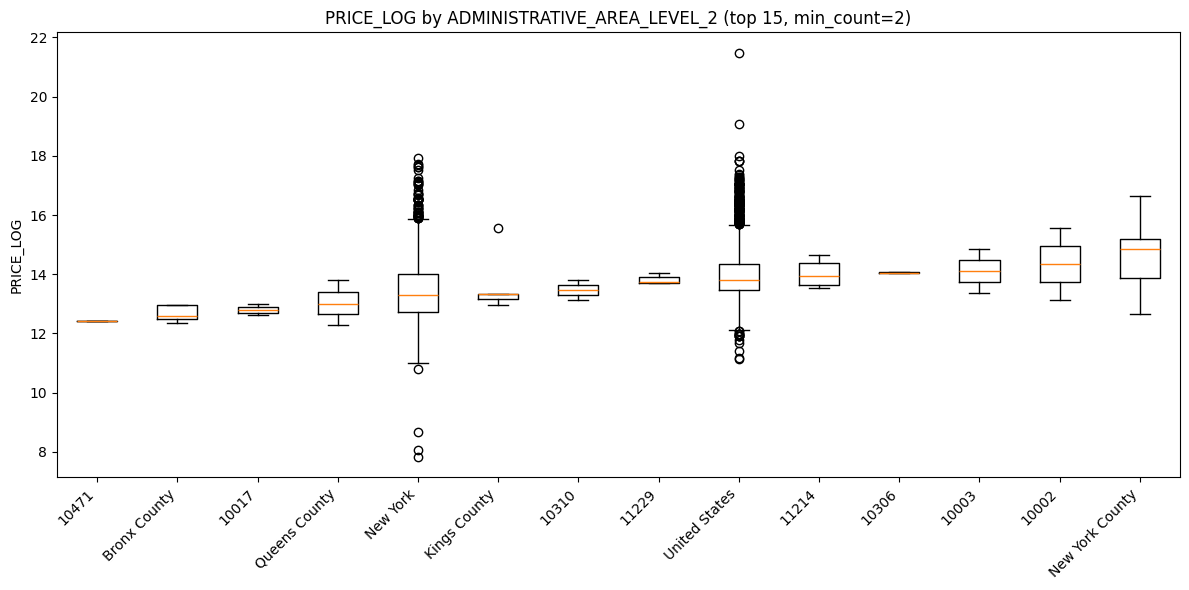

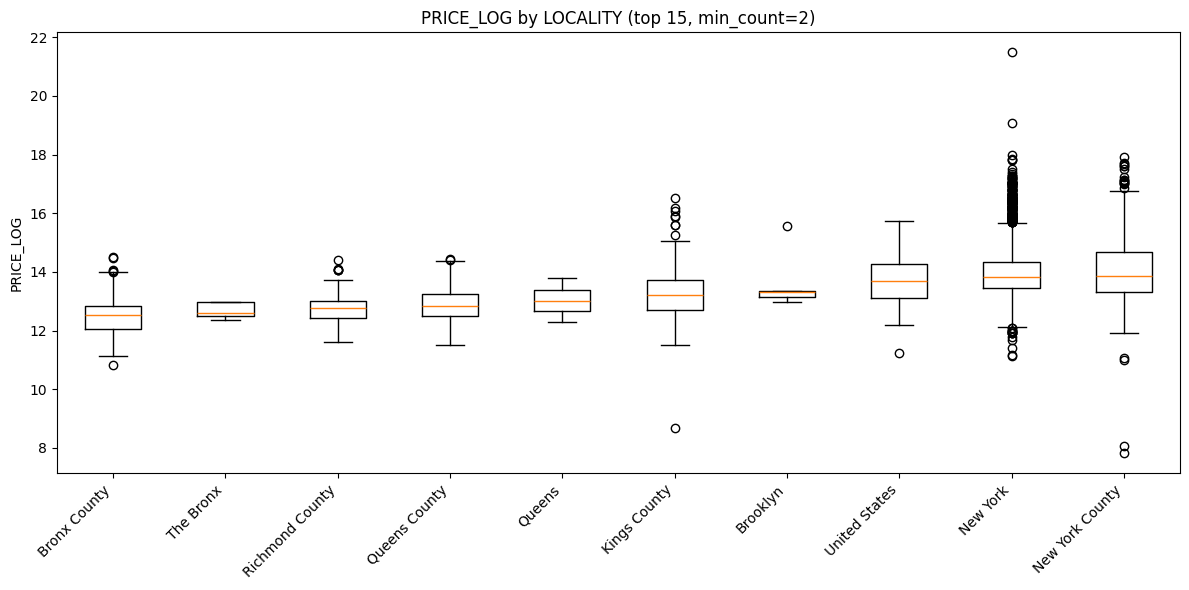

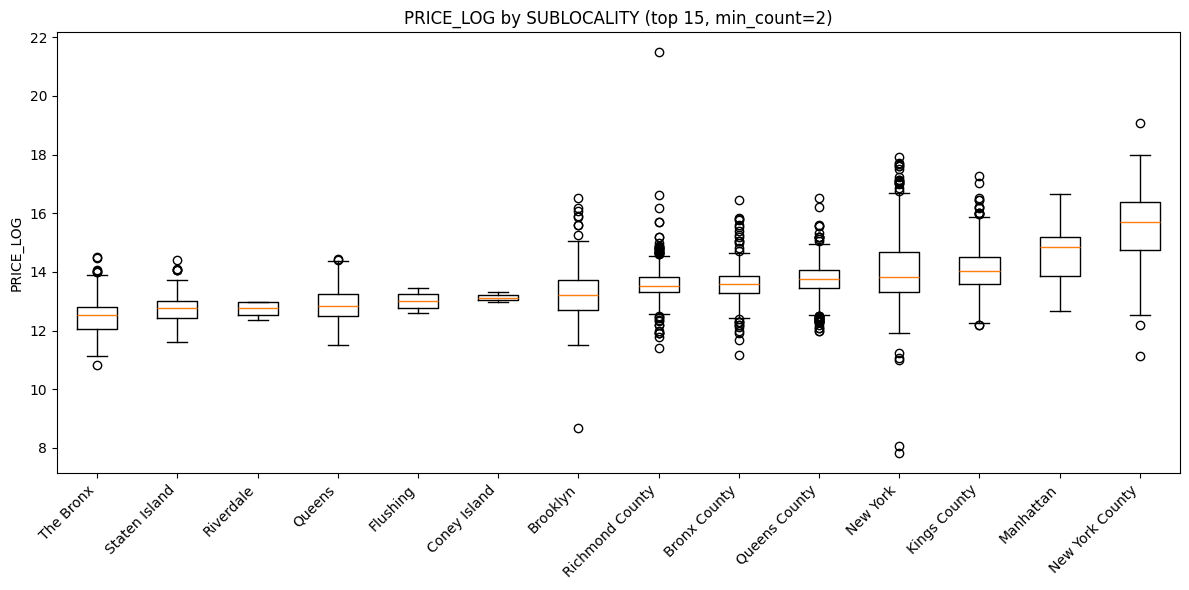

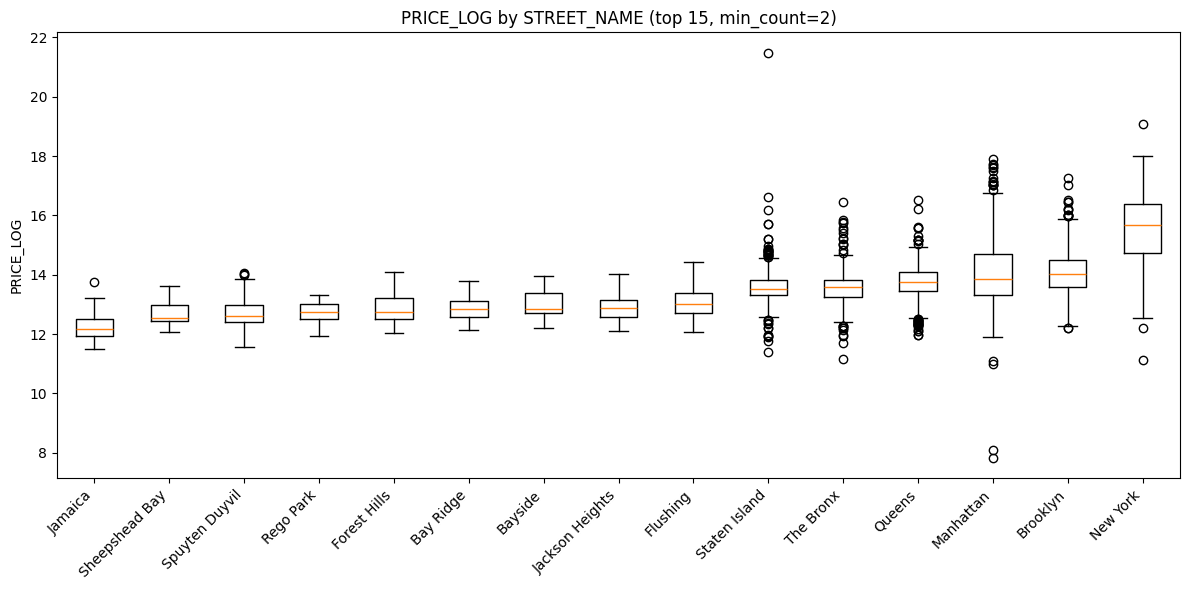

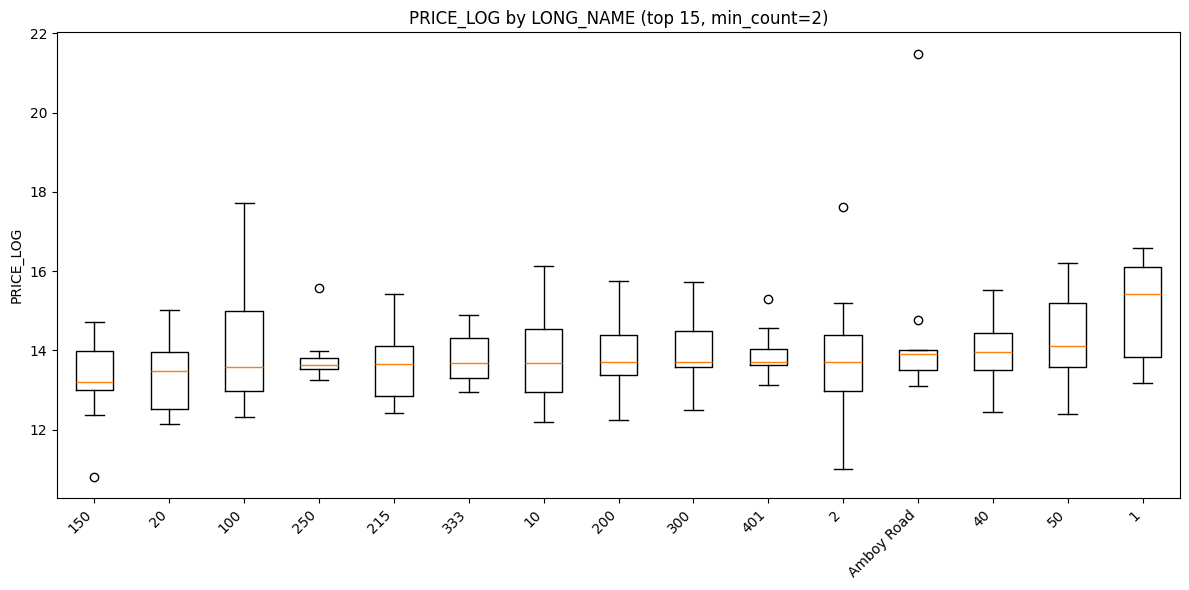

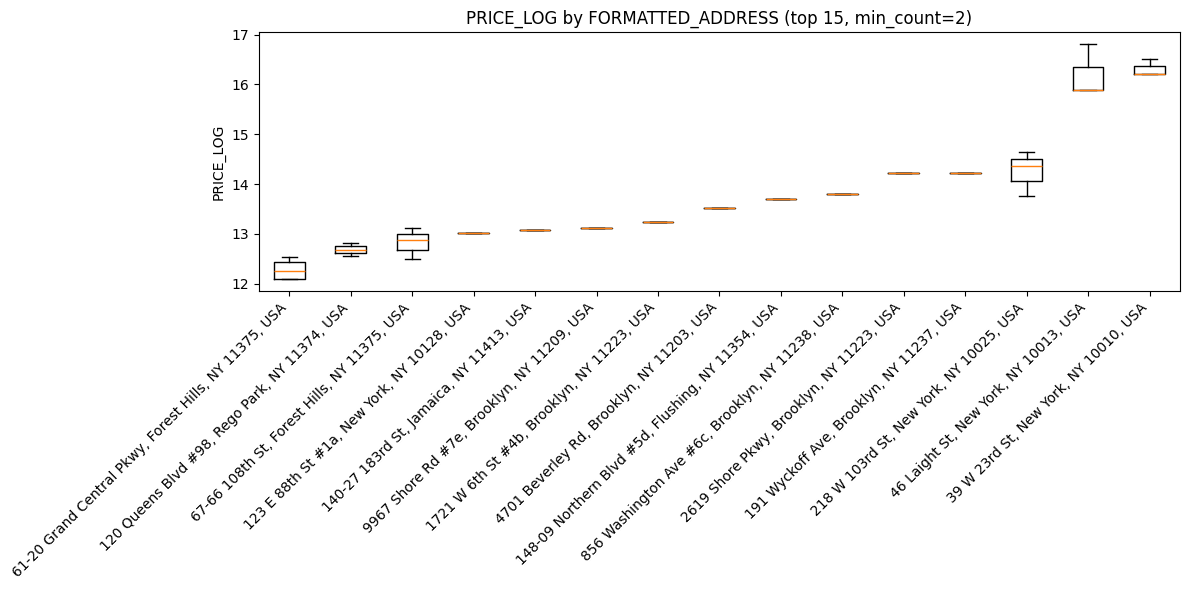

In [29]:
for col in cat_cols:
  boxplot_target_with_cat(df, col,y_col='PRICE_LOG', top_k=15, min_count=2)

# Geographical Analysis

In [30]:
def target_by_group(df, group_col, y_col=TARGET, top_n=15):
  grp = (df.groupby(group_col)[y_col].agg(count="count",
                                         mean="mean",
                                         median="median",
                                         p25=lambda x:x.quantile(0.25),
                                         p75=lambda x:x.quantile(0.75))
  .sort_values("count", ascending=False)
  .head(top_n))

  return grp


In [31]:
print("\nPrice summary by STATE:")
display(target_by_group(df, "STATE"))

print("\nLog Price summary by STATE:")
display(target_by_group(df, "STATE", "PRICE_LOG"))


Price summary by STATE:


,count,mean,median,p25,p75
STATE,,,,,
"Brooklyn, NY 11235",102,8.962741e+05,608999.5,331000.00,1236000.0
"Brooklyn, NY 11209",94,1.211250e+06,599000.0,388250.00,1318500.0
"Forest Hills, NY 11375",91,5.607073e+05,395000.0,272497.50,619500.0
"Brooklyn, NY 11234",90,9.913319e+05,800000.0,649000.00,1198750.0
"Staten Island, NY 10314",86,7.071806e+05,699450.0,591291.00,843975.0
"Bronx, NY 10463",79,7.206678e+05,385000.0,261200.00,675000.0
"Staten Island, NY 10312",73,1.098239e+06,880000.0,649000.00,1348888.0
"Staten Island, NY 10306",69,7.480612e+05,675000.0,395000.00,898000.0
"Brooklyn, NY 11201",60,3.869463e+06,1735000.0,742500.00,5925000.0



Log Price summary by STATE:


,count,mean,median,p25,p75
STATE,,,,,
"Brooklyn, NY 11235",102,13.427038,13.319465,12.709395,14.027248
"Brooklyn, NY 11209",94,13.550447,13.303019,12.869303,14.091969
"Forest Hills, NY 11375",91,12.984236,12.886644,12.515346,13.333336
"Brooklyn, NY 11234",90,13.584248,13.592368,13.383190,13.996789
"Staten Island, NY 10314",86,13.423221,13.458051,13.290041,13.645802
"Bronx, NY 10463",79,13.027172,12.861001,12.473033,13.421783
"Staten Island, NY 10312",73,13.750515,13.687678,13.383190,14.114792
"Staten Island, NY 10306",69,13.361285,13.422469,12.886644,13.707926
"Brooklyn, NY 11201",60,14.502519,14.366253,13.517624,15.594691


In [32]:
print("\nPrice summary by LOCALITY:")
display(target_by_group(df, "LOCALITY"))

print("\nLog Price summary by LOCALITY:")
display(target_by_group(df, "LOCALITY", "PRICE_LOG"))


Price summary by LOCALITY:


,count,mean,median,p25,p75
LOCALITY,,,,,
New York,2505,3.190146e+06,995000.0,699000.0,1699000.0
New York County,979,2.579619e+06,1050000.0,605000.0,2412500.0
Queens County,557,4.430085e+05,375000.0,265000.0,568000.0
Kings County,464,8.646435e+05,554000.0,329000.0,908000.0
Bronx County,182,3.376565e+05,279900.0,171250.0,372425.0
Richmond County,59,4.475819e+05,350000.0,249999.0,452500.0
United States,37,1.327848e+06,880000.0,499000.0,1590000.0
Queens,6,5.173333e+05,453000.0,316250.0,658750.0
Brooklyn,6,1.426167e+06,607000.0,517250.0,622500.0



Log Price summary by LOCALITY:


,count,mean,median,p25,p75
LOCALITY,,,,,
New York,2505,14.010482,13.810499,13.457407,14.345551
New York County,979,14.082223,13.864302,13.312951,14.696161
Queens County,557,12.857309,12.834684,12.487489,13.249878
Kings County,464,13.289145,13.224896,12.703816,13.718855
Bronx County,182,12.514719,12.542191,12.050806,12.827727
Richmond County,59,12.837946,12.765691,12.429216,13.022530
United States,37,13.676696,13.687678,13.120363,14.279245
Queens,6,13.025977,13.005728,12.660112,13.391960
Brooklyn,6,13.603747,13.316199,13.152377,13.341476


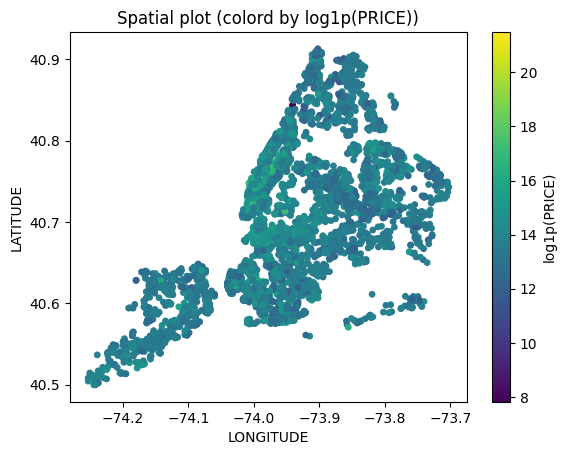

In [33]:
# Spatial plot
geo = df[['LONGITUDE', 'LATITUDE', TARGET]].dropna()
color = np.log1p(geo[TARGET])

plt.figure()
plt.scatter(geo['LONGITUDE'], geo['LATITUDE'], c=color, s=15)
plt.title("Spatial plot (colord by log1p(PRICE))")
plt.xlabel('LONGITUDE')
plt.ylabel('LATITUDE')
plt.colorbar(label='log1p(PRICE)')
plt.show()

In [34]:
def iqr_outliers(df, col, k=1.5):
  s = df[col].dropna()
  q1, q2 = s.quantile(0.25), s.quantile(0.75)
  iqr = q2 - q1
  lo, hi = q1 - k*iqr, q2 + k*iqr
  outliers = df[(df[col] < lo) | (df[col] > hi)].index
  return lo, hi, outliers


In [35]:
o_report = []
num_cols.append('PRICE_LOG')
for col in [TARGET] + num_cols:
  lo, hi, i = iqr_outliers(df, col)
  o_report.append({"Column": col,
                   "Low": lo,
                   "High": hi,
                   "Outlier Count": len(i),
                   "Outlier Percentage": len(i)/len(df) * 100})

o_df = pd.DataFrame(o_report).sort_values("Outlier Count", ascending=False)
print("\nIQR Outlier Report:")
display(o_df)


IQR Outlier Report:


,Column,Low,High,Outlier Count,Outlier Percentage
0,PRICE,-995000.000000,2.989000e+06,559,11.643408
3,PROPERTYSQFT,-276.311793,3.660520e+03,390,8.123308
1,BEDS,-1.000000,7.000000e+00,224,4.665695
6,PRICE_LOG,11.474452,1.586355e+01,218,4.540721
5,LONGITUDE,-74.161902,-7.369588e+01,168,3.499271
2,BATH,-2.000000,6.000000e+00,111,2.312018
4,LATITUDE,40.440554,4.097074e+01,0,0.000000


In [36]:
def zscore_outliers(df, col, z=2.0):
  s = df[col].dropna()
  mu, si = s.mean(), s.std(ddof=0)

  if si == 0 or np.isnan(si):
    return np.array([], dtype=int)

  zscore = (df[col] - mu) / si
  return df[(zscore.abs() > z) & df[col].notna()].index


In [37]:
z_report = []
for col in [TARGET] + num_cols:
  idx = zscore_outliers(df, col)
  z_report.append({"Column": col,
                   "Z_Score_Outlier_Count": len(idx),
                   "Z_Score_Outlier_Percentage": len(idx)/len(df) * 100})

z_df = pd.DataFrame(z_report).sort_values("Z_Score_Outlier_Percentage", ascending=False)
print("\nOutliers with Z scores:")
display(z_df)


Outliers with Z scores:


,Column,Z_Score_Outlier_Count,Z_Score_Outlier_Percentage
5,LONGITUDE,334,6.956884
6,PRICE_LOG,250,5.207248
4,LATITUDE,176,3.665903
1,BEDS,140,2.916059
2,BATH,111,2.312018
3,PROPERTYSQFT,94,1.957925
0,PRICE,2,0.041658


# Data Cleaning
## Config

In [38]:
TARGET = "PRICE"
GROUP_COL = "LOCALITY"

MIN_PRICE = 10_000
MAX_SQFT = 20_000
MIN_SQFT = 100
MAX_BEDS = 20
MAX_BATH = 15

In [39]:
def normalize_text(s):
  s = s.astype(str)
  s = s.str.strip()
  s = s.str.replace(r"\s+", " ", regex=True)
  s = s.str.lower()
  return s

In [40]:
def replace_placeholders_with_nan(s):
  placeholders = {"unknown", "n/a", "null", "none", "", "na", "nan"}
  s2 = normalize_text(s)
  return s2.mask(s.isin(placeholders), np.nan)

In [41]:
def cap_series_by_quantile(s, lo=0.01, hi=0.99):
  s_clean = s.dropna()
  low_cap = s_clean.quantile(lo)
  high_cap = s_clean.quantile(hi)
  return s_clean.clip(lower=low_cap, upper=high_cap), (low_cap, high_cap)

In [42]:
df.columns

Index(['BROKERTITLE', 'TYPE', 'PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT',
       'ADDRESS', 'STATE', 'MAIN_ADDRESS', 'ADMINISTRATIVE_AREA_LEVEL_2',
       'LOCALITY', 'SUBLOCALITY', 'STREET_NAME', 'LONG_NAME',
       'FORMATTED_ADDRESS', 'LATITUDE', 'LONGITUDE', 'PRICE_LOG'],
      dtype='object')

In [43]:
def add_quality_flags(df):
  out = df.copy()

  out["FLAG_PRICE_NONPOS"] = (out[TARGET] <= 0)

  out["FLAG_SQFT_NONPOS"] = (out["PROPERTYSQFT"] <= 0)
  out["FLAG_SQFT_UNREAL"] = (out["PROPERTYSQFT"] < MIN_SQFT) | (out["PROPERTYSQFT"] > MAX_SQFT)

  out["FLAG_BEDS_UNREAL"] = (out["BEDS"] < 0) | (out["BEDS"] > MAX_BEDS)
  out["FLAG_BATH_UNREAL"] = (out["BATH"] < 0) | (out["BEDS"] > MAX_BEDS)

  out["FLAG_BATH_GT_BEDS_PLUS2"] = (out["BATH"] > out["BEDS"]+2)

  return out


In [44]:
df2 = df.copy()

In [45]:
for c in cat_cols:
  df2[c] = replace_placeholders_with_nan(df2[c])

In [46]:
exact_duplicates = df2.duplicated().sum()
print("Exact duplicate rows count:", exact_duplicates)

Exact duplicate rows count: 214


In [47]:
if exact_duplicates > 0:
  df2 = df2.drop_duplicates().reset_index(drop=True)

In [48]:
df2.head()

,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE,PRICE_LOG
0,brokered by douglas elliman -111 fifth ave,condo for sale,315000,2,2.000000,1400.0,2 e 55th st unit 803,"new york, ny 10022","2 e 55th st unit 803new york, ny 10022",new york county,new york,manhattan,east 55th street,regis residence,"regis residence, 2 e 55th st #803, new york, n...",40.761255,-73.974483,12.660331
1,brokered by serhant,condo for sale,195000000,7,10.000000,17545.0,central park tower penthouse-217 w 57th new yo...,"new york, ny 10019",central park tower penthouse-217 w 57th new yo...,united states,new york,new york county,new york,west 57th street,"217 w 57th st, new york, ny 10019, usa",40.766393,-73.980991,19.088510
2,brokered by sowae corp,house for sale,260000,4,2.000000,2015.0,620 sinclair ave,"staten island, ny 10312","620 sinclair avestaten island, ny 10312",united states,new york,richmond county,staten island,sinclair avenue,"620 sinclair ave, staten island, ny 10312, usa",40.541805,-74.196109,12.468441
3,brokered by compass,condo for sale,69000,3,1.000000,445.0,2 e 55th st unit 908w33,"manhattan, ny 10022","2 e 55th st unit 908w33manhattan, ny 10022",united states,new york,new york county,new york,east 55th street,"2 e 55th st, new york, ny 10022, usa",40.761398,-73.974613,11.141876
4,brokered by sotheby's international realty - e...,townhouse for sale,55000000,7,2.373861,14175.0,5 e 64th st,"new york, ny 10065","5 e 64th stnew york, ny 10065",united states,new york,new york county,new york,east 64th street,"5 e 64th st, new york, ny 10065, usa",40.767224,-73.969856,17.822844


In [49]:
addr_price_count = (df2.groupby("FORMATTED_ADDRESS")[TARGET]
                    .nunique()
                    .sort_values(ascending=False))
print("Top addresses with multiple unique price values:")
display(addr_price_count.head(10))

Top addresses with multiple unique price values:


,PRICE
FORMATTED_ADDRESS,
"61-20 grand central pkwy, forest hills, ny 11375, usa",3
"120 queens blvd #98, rego park, ny 11374, usa",3
"67-66 108th st, forest hills, ny 11375, usa",3
"218 w 103rd st, new york, ny 10025, usa",3
"97-40 62nd dr, rego park, ny 11374, usa",2
"9011 35th ave apt 1f, jackson heights, ny 11372, usa",2
"1100 clove rd, staten island, ny 10301, usa",2
"34-41 85th st #3a, flushing, ny 11372, usa",2
"35-31 85th st, jackson heights, ny 11372, usa",2


In [50]:
top_addr = addr_price_count.index[9]
df2[df2['FORMATTED_ADDRESS'] == top_addr]

,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE,PRICE_LOG
1557,brokered by pantiga group inc.,co-op for sale,259000,2,1.0,950.0,800 grand concourse ave unit gjn,"bronx, ny 10451","800 grand concourse ave unit gjnbronx, ny 10451",united states,new york,bronx county,the bronx,grand concourse,"800 grand concourse, bronx, ny 10451, usa",40.82487,-73.922983,12.464587
4546,brokered by compass,co-op for sale,275000,2,1.0,815.0,800 grand concourse apt gms,"bronx, ny 10451","800 grand concourse apt gmsbronx, ny 10451",united states,new york,bronx county,the bronx,grand concourse,"800 grand concourse, bronx, ny 10451, usa",40.82487,-73.922983,12.524530


In [51]:
df2 = add_quality_flags(df2)

In [52]:
print("\nQuality Flag Counts:")
flag_col = [c for c in df2.columns if c.startswith("FLAG_")]
print(flag_col)
display(df2[flag_col].sum().sort_values(ascending=False).to_frame("count"))


Quality Flag Counts:
['FLAG_PRICE_NONPOS', 'FLAG_SQFT_NONPOS', 'FLAG_SQFT_UNREAL', 'FLAG_BEDS_UNREAL', 'FLAG_BATH_UNREAL', 'FLAG_BATH_GT_BEDS_PLUS2']


,count
FLAG_BATH_GT_BEDS_PLUS2,19
FLAG_BEDS_UNREAL,11
FLAG_BATH_UNREAL,11
FLAG_SQFT_UNREAL,10
FLAG_SQFT_NONPOS,0
FLAG_PRICE_NONPOS,0


In [53]:
df2[df2["FLAG_BATH_GT_BEDS_PLUS2"]]

,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE,PRICE_LOG,FLAG_PRICE_NONPOS,FLAG_SQFT_NONPOS,FLAG_SQFT_UNREAL,FLAG_BEDS_UNREAL,FLAG_BATH_UNREAL,FLAG_BATH_GT_BEDS_PLUS2
1,brokered by serhant,condo for sale,195000000,7,10.0,17545.000000,central park tower penthouse-217 w 57th new yo...,"new york, ny 10019",central park tower penthouse-217 w 57th new yo...,united states,new york,new york county,new york,west 57th street,"217 w 57th st, new york, ny 10019, usa",40.766393,-73.980991,19.088510,False,False,False,False,False,True
7,brokered by connie profaci realty,house for sale,16800000,8,16.0,33000.000000,177 benedict rd,"staten island, ny 10304","177 benedict rdstaten island, ny 10304",united states,new york,richmond county,staten island,benedict road,"177 benedict rd, staten island, ny 10304, usa",40.595002,-74.106424,16.636890,False,False,True,False,False,True
603,brokered by momentum real estate llc,multi-family home for sale,3000000,3,32.0,11760.000000,8001 new utrecht ave,"brooklyn, ny 11214","8001 new utrecht avebrooklyn, ny 11214",united states,new york,kings county,brooklyn,new utrecht avenue,"8001 new utrecht ave, brooklyn, ny 11214, usa",40.611548,-74.000866,14.914123,False,False,False,False,False,True
612,brokered by sotheby's international realty - d...,townhouse for sale,29950000,10,13.0,8750.000000,26 washington sq n,"new york, ny 10011","26 washington sq nnew york, ny 10011",united states,new york,new york county,new york,washington square west,"26 washington square w, new york, ny 10011, usa",40.732221,-73.998628,17.215040,False,False,False,False,False,True
640,brokered by a p services inc,multi-family home for sale,2295000,3,7.0,2184.207862,4415 atlantic ave,"brooklyn, ny 11224","4415 atlantic avebrooklyn, ny 11224",united states,new york,kings county,brooklyn,atlantic avenue,"4415 atlantic ave, brooklyn, ny 11224, usa",40.575795,-74.009975,14.646244,False,False,False,False,False,True
1201,"brokered by nest seekers international, midtown",townhouse for sale,8950000,3,6.0,6336.000000,209 e 31st st,"new york, ny 10016","209 e 31st stnew york, ny 10016",united states,new york,new york county,new york,east 31st street,"209 e 31st st, new york, ny 10016, usa",40.743741,-73.978774,16.007164,False,False,False,False,False,True
1220,brokered by corcoran west side,multi-family home for sale,34000000,3,8.0,2184.207862,217 w 21st st,"new york, ny 10011","217 w 21st stnew york, ny 10011",united states,new york,new york county,new york,west 21st street,"217 w 21st st, new york, ny 10011, usa",40.743390,-73.997378,17.341871,False,False,False,False,False,True
1523,brokered by brown harris stevens,townhouse for sale,1595000,3,8.0,2184.207862,511 w 144th st unit townhouse,"manhattan, ny 10031","511 w 144th st unit townhousemanhattan, ny 10031",united states,new york,new york county,new york,west 144th street,"511 w 144th st, new york, ny 10031, usa",40.825007,-73.948645,14.282385,False,False,False,False,False,True
1795,brokered by geo real estate group inc,multi-family home for sale,999000,3,6.0,2184.207862,590 maple st,"brooklyn, ny 11203","590 maple stbrooklyn, ny 11203",united states,new york,kings county,brooklyn,maple street,"590 maple st, brooklyn, ny 11203, usa",40.661217,-73.941228,13.814511,False,False,False,False,False,True
3298,"brokered by dom realty, inc",multi-family home for sale,1085000,3,8.0,3480.000000,2764 w 15th st,"brooklyn, ny 11224","2764 w 15th stbrooklyn, ny 11224",united states,new york,kings county,brooklyn,west 15th street,"2764 w 15th st, brooklyn, ny 11224, usa",40.580148,-73.983584,13.897091,False,False,False,False,False,True


In [54]:
df2[df2["FLAG_BEDS_UNREAL"]]

,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE,PRICE_LOG,FLAG_PRICE_NONPOS,FLAG_SQFT_NONPOS,FLAG_SQFT_UNREAL,FLAG_BEDS_UNREAL,FLAG_BATH_UNREAL,FLAG_BATH_GT_BEDS_PLUS2
746,brokered by re max edge,multi-family home for sale,4380000,35,16.0,15000.0,8699 bay pkwy unit 16,"brooklyn, ny 11214","8699 bay pkwy unit 16brooklyn, ny 11214",united states,new york,kings county,brooklyn,8699,"8699 bay pkwy #16, brooklyn, ny 11214, usa",40.599715,-73.995694,15.292560,False,False,False,True,True,False
1059,brokered by christie's int.real estate group,house for sale,3500000,24,8.0,9500.0,29 hampton pl,"brooklyn, ny 11213","29 hampton plbrooklyn, ny 11213",united states,new york,kings county,brooklyn,hampton place,"29 hampton pl, brooklyn, ny 11213, usa",40.671795,-73.940735,15.068274,False,False,False,True,True,False
1110,brokered by blue key real estate brokerage,multi-family home for sale,11000000,50,50.0,22035.0,8820 avenue j,"brooklyn, ny 11236","8820 avenue jbrooklyn, ny 11236",united states,new york,kings county,brooklyn,avenue j,"8820 avenue j, brooklyn, ny 11236, usa",40.637696,-73.904836,16.213406,False,False,True,True,True,False
2184,brokered by coldwell banker reliable,house for sale,4000000,32,12.0,7188.0,150 e 105th st,"new york, ny 10029","150 e 105th stnew york, ny 10029",united states,new york,new york county,new york,east 105th street,"150 e 105th st, new york, ny 10029, usa",40.791288,-73.946522,15.201805,False,False,False,True,True,False
2396,brokered by re max real estate professionals,multi-family home for sale,3099000,36,16.0,12460.0,5206 6th ave,"brooklyn, ny 11220","5206 6th avebrooklyn, ny 11220",united states,new york,kings county,brooklyn,6th avenue,"5206 6th ave, brooklyn, ny 11220, usa",40.642652,-74.009674,14.946590,False,False,False,True,True,False
2469,brokered by coldwell banker american homes,multi-family home for sale,2700000,24,24.0,18936.0,3520 newkirk ave unit 24,"brooklyn, ny 11203","3520 newkirk ave unit 24brooklyn, ny 11203",new york,kings county,brooklyn,little haiti,3520,"3520 newkirk ave #24, brooklyn, ny 11203, usa",40.640181,-73.942939,14.808763,False,False,False,True,True,False
2550,brokered by neuhaus realty inc.,multi-family home for sale,10700000,42,43.0,27152.0,646-662 port richmond ave,"staten island, ny 10302","646-662 port richmond avestaten island, ny 10302",united states,new york,richmond county,staten island,port richmond avenue,"646 port richmond ave, staten island, ny 10302...",40.627671,-74.142352,16.185754,False,False,True,True,True,False
3154,brokered by weichert realtors tmt group,multi-family home for sale,5980000,40,20.0,15500.0,35-54 95th st,"jackson heights, ny 11372","35-54 95th stjackson heights, ny 11372",united states,new york,queens county,queens,95th street,"35-54 95th st, flushing, ny 11372, usa",40.751468,-73.872619,15.603931,False,False,False,True,True,False
3450,brokered by coldwell banker reliable real estate,multi-family home for sale,4000000,32,12.0,7200.0,154 e 105th st,"new york, ny 10029","154 e 105th stnew york, ny 10029",united states,new york,new york county,new york,east 105th street,"154 e 105th st, new york, ny 10029, usa",40.791206,-73.946512,15.201805,False,False,False,True,True,False
3463,brokered by bhhs fillmore r.e.,multi-family home for sale,3500000,30,20.0,18400.0,1319 newkirk ave,"brooklyn, ny 11230","1319 newkirk avebrooklyn, ny 11230",united states,new york,kings county,brooklyn,newkirk avenue,"1319 newkirk ave, brooklyn, ny 11230, usa",40.635180,-73.964614,15.068274,False,False,False,True,True,False


In [55]:
df2[df2["FLAG_BATH_UNREAL"]]

,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE,PRICE_LOG,FLAG_PRICE_NONPOS,FLAG_SQFT_NONPOS,FLAG_SQFT_UNREAL,FLAG_BEDS_UNREAL,FLAG_BATH_UNREAL,FLAG_BATH_GT_BEDS_PLUS2
746,brokered by re max edge,multi-family home for sale,4380000,35,16.0,15000.0,8699 bay pkwy unit 16,"brooklyn, ny 11214","8699 bay pkwy unit 16brooklyn, ny 11214",united states,new york,kings county,brooklyn,8699,"8699 bay pkwy #16, brooklyn, ny 11214, usa",40.599715,-73.995694,15.292560,False,False,False,True,True,False
1059,brokered by christie's int.real estate group,house for sale,3500000,24,8.0,9500.0,29 hampton pl,"brooklyn, ny 11213","29 hampton plbrooklyn, ny 11213",united states,new york,kings county,brooklyn,hampton place,"29 hampton pl, brooklyn, ny 11213, usa",40.671795,-73.940735,15.068274,False,False,False,True,True,False
1110,brokered by blue key real estate brokerage,multi-family home for sale,11000000,50,50.0,22035.0,8820 avenue j,"brooklyn, ny 11236","8820 avenue jbrooklyn, ny 11236",united states,new york,kings county,brooklyn,avenue j,"8820 avenue j, brooklyn, ny 11236, usa",40.637696,-73.904836,16.213406,False,False,True,True,True,False
2184,brokered by coldwell banker reliable,house for sale,4000000,32,12.0,7188.0,150 e 105th st,"new york, ny 10029","150 e 105th stnew york, ny 10029",united states,new york,new york county,new york,east 105th street,"150 e 105th st, new york, ny 10029, usa",40.791288,-73.946522,15.201805,False,False,False,True,True,False
2396,brokered by re max real estate professionals,multi-family home for sale,3099000,36,16.0,12460.0,5206 6th ave,"brooklyn, ny 11220","5206 6th avebrooklyn, ny 11220",united states,new york,kings county,brooklyn,6th avenue,"5206 6th ave, brooklyn, ny 11220, usa",40.642652,-74.009674,14.946590,False,False,False,True,True,False
2469,brokered by coldwell banker american homes,multi-family home for sale,2700000,24,24.0,18936.0,3520 newkirk ave unit 24,"brooklyn, ny 11203","3520 newkirk ave unit 24brooklyn, ny 11203",new york,kings county,brooklyn,little haiti,3520,"3520 newkirk ave #24, brooklyn, ny 11203, usa",40.640181,-73.942939,14.808763,False,False,False,True,True,False
2550,brokered by neuhaus realty inc.,multi-family home for sale,10700000,42,43.0,27152.0,646-662 port richmond ave,"staten island, ny 10302","646-662 port richmond avestaten island, ny 10302",united states,new york,richmond county,staten island,port richmond avenue,"646 port richmond ave, staten island, ny 10302...",40.627671,-74.142352,16.185754,False,False,True,True,True,False
3154,brokered by weichert realtors tmt group,multi-family home for sale,5980000,40,20.0,15500.0,35-54 95th st,"jackson heights, ny 11372","35-54 95th stjackson heights, ny 11372",united states,new york,queens county,queens,95th street,"35-54 95th st, flushing, ny 11372, usa",40.751468,-73.872619,15.603931,False,False,False,True,True,False
3450,brokered by coldwell banker reliable real estate,multi-family home for sale,4000000,32,12.0,7200.0,154 e 105th st,"new york, ny 10029","154 e 105th stnew york, ny 10029",united states,new york,new york county,new york,east 105th street,"154 e 105th st, new york, ny 10029, usa",40.791206,-73.946512,15.201805,False,False,False,True,True,False
3463,brokered by bhhs fillmore r.e.,multi-family home for sale,3500000,30,20.0,18400.0,1319 newkirk ave,"brooklyn, ny 11230","1319 newkirk avebrooklyn, ny 11230",united states,new york,kings county,brooklyn,newkirk avenue,"1319 newkirk ave, brooklyn, ny 11230, usa",40.635180,-73.964614,15.068274,False,False,False,True,True,False


In [56]:
df2[df2['FLAG_SQFT_UNREAL']]

,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE,PRICE_LOG,FLAG_PRICE_NONPOS,FLAG_SQFT_NONPOS,FLAG_SQFT_UNREAL,FLAG_BEDS_UNREAL,FLAG_BATH_UNREAL,FLAG_BATH_GT_BEDS_PLUS2
7,brokered by connie profaci realty,house for sale,16800000,8,16.000000,33000.0,177 benedict rd,"staten island, ny 10304","177 benedict rdstaten island, ny 10304",united states,new york,richmond county,staten island,benedict road,"177 benedict rd, staten island, ny 10304, usa",40.595002,-74.106424,16.636890,False,False,True,False,False,True
138,brokered by douglas elliman - 575 madison ave,house for sale,56000000,11,10.000000,24000.0,9 w 54th st,"new york, ny 10019","9 w 54th stnew york, ny 10019",united states,new york,new york county,new york,west 54th street,"9 w 54th st, new york, ny 10019, usa",40.761600,-73.976191,17.840862,False,False,True,False,False,False
804,brokered by andrew lichtenstein inc,multi-family home for sale,7200000,3,2.373861,48000.0,3650 bronx blvd,"bronx, ny 10467","3650 bronx blvdbronx, ny 10467",united states,new york,bronx county,the bronx,bronx boulevard,"3650 bronx blvd, bronx, ny 10467, usa",40.881464,-73.867129,15.789592,False,False,True,False,False,False
1110,brokered by blue key real estate brokerage,multi-family home for sale,11000000,50,50.000000,22035.0,8820 avenue j,"brooklyn, ny 11236","8820 avenue jbrooklyn, ny 11236",united states,new york,kings county,brooklyn,avenue j,"8820 avenue j, brooklyn, ny 11236, usa",40.637696,-73.904836,16.213406,False,False,True,True,True,False
1979,brokered by link ny realty,multi-family home for sale,2300000,3,2.373861,21000.0,96 e 208th st,"bronx, ny 10467","96 e 208th stbronx, ny 10467",united states,new york,bronx county,the bronx,east 208th street,"96 e 208th st, bronx, ny 10467, usa",40.878193,-73.881807,14.648420,False,False,True,False,False,False
2068,brokered by myc & associates inc,multi-family home for sale,5827000,3,2.373861,55300.0,9944 62nd ave,"queens, ny 11374","9944 62nd avequeens, ny 11374",united states,new york,queens county,queens,62nd avenue,"99-44 62nd ave, flushing, ny 11374, usa",40.735274,-73.856655,15.578013,False,False,True,False,False,False
2550,brokered by neuhaus realty inc.,multi-family home for sale,10700000,42,43.000000,27152.0,646-662 port richmond ave,"staten island, ny 10302","646-662 port richmond avestaten island, ny 10302",united states,new york,richmond county,staten island,port richmond avenue,"646 port richmond ave, staten island, ny 10302...",40.627671,-74.142352,16.185754,False,False,True,True,True,False
2820,brokered by compass,house for sale,14000000,3,2.373861,23027.0,39 eldridge st,"manhattan, ny 10002","39 eldridge stmanhattan, ny 10002",united states,new york,new york county,new york,eldridge street,"39 eldridge st, new york, ny 10002, usa",40.715777,-73.993570,16.454568,False,False,True,False,False,False
3010,brokered by prime ny inc.,multi-family home for sale,6950000,6,6.000000,32000.0,367 e 201st st,"bronx, ny 10458","367 e 201st stbronx, ny 10458",united states,new york,bronx county,the bronx,east 201st street,"367 e 201st st, bronx, ny 10458, usa",40.869460,-73.882195,15.754252,False,False,True,False,False,False
4421,brokered by evergreen realty & investments,multi-family home for sale,31500000,3,2.373861,65535.0,467 keap st,"brooklyn, ny 11211","467 keap stbrooklyn, ny 11211",united states,new york,kings county,brooklyn,keap street,"467 keap st, brooklyn, ny 11211, usa",40.712980,-73.952445,17.265498,False,False,True,False,False,False


In [57]:
df2 = df2[~(df2['FLAG_BATH_GT_BEDS_PLUS2'] & df2['BATH'] > 10.0)].copy()
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4587 entries, 0 to 4586
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   BROKERTITLE                  4587 non-null   object 
 1   TYPE                         4587 non-null   object 
 2   PRICE                        4587 non-null   int64  
 3   BEDS                         4587 non-null   int64  
 4   BATH                         4587 non-null   float64
 5   PROPERTYSQFT                 4587 non-null   float64
 6   ADDRESS                      4587 non-null   object 
 7   STATE                        4587 non-null   object 
 8   MAIN_ADDRESS                 4587 non-null   object 
 9   ADMINISTRATIVE_AREA_LEVEL_2  4587 non-null   object 
 10  LOCALITY                     4587 non-null   object 
 11  SUBLOCALITY                  4587 non-null   object 
 12  STREET_NAME                  4587 non-null   object 
 13  LONG_NAME         

In [58]:
before = len(df2)
df2 = df2[df2[TARGET] > 0].copy()
df2 = df2[df2['PROPERTYSQFT'] > 0].copy()
after = len(df2)

print(f"Hard filtered invalid rows: {before-after} removed")

Hard filtered invalid rows: 0 removed


In [59]:
before = len(df2)
df2 = df2[df2[TARGET] >= MIN_PRICE].copy()
after = len(df2)

print(f"Hard filtered invalid rows: {before-after} removed")

Hard filtered invalid rows: 3 removed


In [60]:
cols_to_drop = ['ADDRESS', 'STATE', 'MAIN_ADDRESS', 'SUBLOCALITY', 'STREET_NAME', 'LONG_NAME',
       'FORMATTED_ADDRESS','FLAG_PRICE_NONPOS', 'FLAG_SQFT_NONPOS', 'FLAG_SQFT_UNREAL',
       'FLAG_BEDS_UNREAL', 'FLAG_BATH_UNREAL', 'FLAG_BATH_GT_BEDS_PLUS2', 'PRICE_LOG']
df2.drop(columns=cols_to_drop, inplace=True)
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4584 entries, 0 to 4586
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   BROKERTITLE                  4584 non-null   object 
 1   TYPE                         4584 non-null   object 
 2   PRICE                        4584 non-null   int64  
 3   BEDS                         4584 non-null   int64  
 4   BATH                         4584 non-null   float64
 5   PROPERTYSQFT                 4584 non-null   float64
 6   ADMINISTRATIVE_AREA_LEVEL_2  4584 non-null   object 
 7   LOCALITY                     4584 non-null   object 
 8   LATITUDE                     4584 non-null   float64
 9   LONGITUDE                    4584 non-null   float64
dtypes: float64(4), int64(2), object(4)
memory usage: 393.9+ KB


In [61]:
df2['LOCALITY'] = df2['LOCALITY'].replace(['new york county', 'new york'], 'new york')
min_counts = 60
counts = df2['LOCALITY'].value_counts()
rare_localities = counts[counts < min_counts].index
df2['LOCALITY'] = df2['LOCALITY'].replace(rare_localities, "others")


In [62]:
df2['LOCALITY'].value_counts()

,count
LOCALITY,
new york,3323
queens county,536
kings county,441
bronx county,172
others,112


In [63]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4584 entries, 0 to 4586
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   BROKERTITLE                  4584 non-null   object 
 1   TYPE                         4584 non-null   object 
 2   PRICE                        4584 non-null   int64  
 3   BEDS                         4584 non-null   int64  
 4   BATH                         4584 non-null   float64
 5   PROPERTYSQFT                 4584 non-null   float64
 6   ADMINISTRATIVE_AREA_LEVEL_2  4584 non-null   object 
 7   LOCALITY                     4584 non-null   object 
 8   LATITUDE                     4584 non-null   float64
 9   LONGITUDE                    4584 non-null   float64
dtypes: float64(4), int64(2), object(4)
memory usage: 393.9+ KB


# Train/Validation split

In [64]:
from sklearn.model_selection import GroupShuffleSplit
if GROUP_COL in df2.columns:
  splitter = GroupShuffleSplit(n_splits=1,
                              test_size=0.2,
                              random_state=42)
  train_i, val_i = next(splitter.split(df2, groups=df2[GROUP_COL]))
  train_df = df2.iloc[train_i].copy()
  val_df = df2.iloc[val_i].copy()
  print(f"Group split by {GROUP_COL}: traiin={len(train_df)} and val={len(val_df)}")
else:
  train_df = df2.sample(frac=0.8, random_state=42).copy()
  val_df = df2.drop(train_df.index).copy()
  print(f"\nRandom split: train={len(train_df)}, val={len(val_df)}")

Group split by LOCALITY: traiin=4143 and val=441


In [65]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4584 entries, 0 to 4586
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   BROKERTITLE                  4584 non-null   object 
 1   TYPE                         4584 non-null   object 
 2   PRICE                        4584 non-null   int64  
 3   BEDS                         4584 non-null   int64  
 4   BATH                         4584 non-null   float64
 5   PROPERTYSQFT                 4584 non-null   float64
 6   ADMINISTRATIVE_AREA_LEVEL_2  4584 non-null   object 
 7   LOCALITY                     4584 non-null   object 
 8   LATITUDE                     4584 non-null   float64
 9   LONGITUDE                    4584 non-null   float64
dtypes: float64(4), int64(2), object(4)
memory usage: 393.9+ KB


In [66]:
df['PROPERTYSQFT'].describe()

,PROPERTYSQFT
count,4801.000000
mean,2184.207862
std,2377.140894
min,230.000000
25%,1200.000000
50%,2184.207862
75%,2184.207862
max,65535.000000


In [67]:
def engineer_nonkey_features(df_in):
  out = df_in.copy()

  # out['PRICE_PER_SQFT'] = out[TARGET] / out['PROPERTYSQFT']
  out['TOTAL_ROOMS_PROXY'] = out['BEDS'] + out['BATH']

  out['BED_TO_BATH_RATIO'] = out['BEDS'] / out["BATH"].replace(0, np.nan)

  out['SQFT_SIZE_BINS'] = pd.cut(out['PROPERTYSQFT'],
                                 bins=[0, 800, 1600, 3000, np.inf],
                                 labels=["samll", "medium", "large", "very_large"])

  out['BEDS_X_SQFT'] = out['BEDS'] * out['PROPERTYSQFT']

  out['PRICE_LOG'] = np.log1p(df_in['PRICE'])

  return out



In [68]:
train_df = engineer_nonkey_features(train_df)
val_df = engineer_nonkey_features(val_df)

# Modleing, pipelines, tuning, evaluation

In [69]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import mean_absolute_error, mean_squared_log_error, r2_score
from sklearn.model_selection import GroupKFold, KFold, RandomizedSearchCV

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

In [70]:
TARGET = "PRICE"
LOG_TARGET = "PRICE_LOG"

In [71]:
GROUP_COL = "LOCALITY"
RANDON_SEED = 42

## Define evaluation helpers

In [72]:
def rmse(x):
  return float(np.sqrt(np.mean(np.square(x))))

In [73]:
def evaluate_regression(y_true, y_pred, prefix=""):
  mae = mean_absolute_error(y_true=y_true, y_pred=y_pred)

  y_true_clip = np.clip(y_true, 0, None)
  y_pred_clip = np.clip(y_pred, 0, None)
  rmsle = np.sqrt(mean_squared_log_error(y_true_clip, y_pred_clip))

  r2 = r2_score(y_true, y_pred)

  return {
      f"{prefix}MAE": mae,
      f"{prefix}RMSLE": rmsle,
      f"{prefix}R2": r2
  }

In [74]:
def predict_from_log(model, X):
  y_pred_log = model.predict(X)
  y_pred_raw = np.expm1(y_pred_log)
  return y_pred_raw

In [75]:
def error_analysis_plot(y_true, y_pred, title="Pred vs True"):
  plt.figure()
  plt.scatter(y_true, y_pred, s=8)
  plt.title(title)
  plt.xlabel("True PRICE")
  plt.ylabel("Predicted PRICE")
  plt.show()

In [76]:
cols_to_drop = ['PRICE', 'PRICE_PER_SQFT', 'PRICE_LOG']
features_col = [c for c in train_df.columns if c not in cols_to_drop]
print("Dropping:\n", cols_to_drop)
print("Keeping:\n", features_col)

Dropping:
 ['PRICE', 'PRICE_PER_SQFT', 'PRICE_LOG']
Keeping:
 ['BROKERTITLE', 'TYPE', 'BEDS', 'BATH', 'PROPERTYSQFT', 'ADMINISTRATIVE_AREA_LEVEL_2', 'LOCALITY', 'LATITUDE', 'LONGITUDE', 'TOTAL_ROOMS_PROXY', 'BED_TO_BATH_RATIO', 'SQFT_SIZE_BINS', 'BEDS_X_SQFT']


In [77]:
X_train = train_df[features_col].copy()
y_train_log = train_df[LOG_TARGET].astype(float).copy()

X_val = val_df[features_col].copy()
y_val_raw = val_df[TARGET].astype(float).copy()

In [78]:
num_features = X_train.select_dtypes(include=[np.number]).columns.to_list()
cat_features = X_train.select_dtypes(include=['object', 'bool']).columns.to_list()
print(f"Numeric features: {num_features}")
print(f"Categorial features: {cat_features}")

Numeric features: ['BEDS', 'BATH', 'PROPERTYSQFT', 'LATITUDE', 'LONGITUDE', 'TOTAL_ROOMS_PROXY', 'BED_TO_BATH_RATIO', 'BEDS_X_SQFT']
Categorial features: ['BROKERTITLE', 'TYPE', 'ADMINISTRATIVE_AREA_LEVEL_2', 'LOCALITY']


# Preprocessing pipelines

In [79]:
numeric_trasformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ])
categorical_transfomer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_trasformer, num_features),
        ("cat", categorical_transfomer, cat_features),
    ],
    remainder="drop"
)

# Cross validation

In [80]:
use_group_cv = GROUP_COL in train_df.columns
if use_group_cv:
  groups = train_df[GROUP_COL].astype(str).fillna("missing").values
  cv = GroupKFold(n_splits=5)
  print(f"CV: GroupKFold by {GROUP_COL}")
else:
  groups = None
  cv = KFold(n_splits=5, shuffle=True, random_state=RANDON_SEED)
  print("CV: KFold (random)")

CV: GroupKFold by LOCALITY


# Model Candidates

In [81]:
models = {
    "DummyMedian": DummyRegressor(strategy="median"),
    "Ridge": Ridge(random_state=RANDON_SEED),
    "HistGB": HistGradientBoostingRegressor(random_state=RANDON_SEED),
    "RandomForest": RandomForestRegressor(n_estimators=400,
                                          random_state=RANDON_SEED,
                                          n_jobs=1),
}

In [82]:
results = []

for name, model in models.items():
  pipe = Pipeline(steps=[
      ("preprocess", preprocess),
      ("model", model),
  ])

  pipe.fit(X_train, y_train_log)

  y_pred_val_raw = predict_from_log(pipe, X_val)

  metrics = evaluate_regression(y_val_raw, y_pred_val_raw, prefix=f"{name}_")
  results.append({
        "model": name,
        "MAE": metrics[f"{name}_MAE"],
        "RMSLE": metrics[f"{name}_RMSLE"],
        "R2": metrics[f"{name}_R2"],
    })

  print(f"\n{name} metrics:")
  for k, v in metrics.items():
    print(f" {k}: {v:,.4f}" if "R2" in k else f" {k}: {v:,.2f}")




DummyMedian metrics:
 DummyMedian_MAE: 602,698.37
 DummyMedian_RMSLE: 0.86
 DummyMedian_R2: -0.0000

Ridge metrics:
 Ridge_MAE: 379,392.54
 Ridge_RMSLE: 0.51
 Ridge_R2: 0.3614

HistGB metrics:
 HistGB_MAE: 274,031.55
 HistGB_RMSLE: 0.41
 HistGB_R2: 0.8011

RandomForest metrics:
 RandomForest_MAE: 269,714.57
 RandomForest_RMSLE: 0.44
 RandomForest_R2: 0.8496


In [83]:
result_df = pd.DataFrame(results)
print("\nModel Comparison (Validation):")
display(result_df)


Model Comparison (Validation):


,model,MAE,RMSLE,R2
0,DummyMedian,602698.369615,0.855086,-0.000003
1,Ridge,379392.538099,0.505801,0.361360
2,HistGB,274031.545238,0.410526,0.801122
3,RandomForest,269714.572957,0.437225,0.849601


In [84]:
results_s = result_df.sort_values(by="RMSLE", ascending=True).reset_index(drop=True)
print(results_s)
best_model = results_s.loc[0, "model"]
print(best_model)
best_model = models[best_model]

          model            MAE     RMSLE        R2
0        HistGB  274031.545238  0.410526  0.801122
1  RandomForest  269714.572957  0.437225  0.849601
2         Ridge  379392.538099  0.505801  0.361360
3   DummyMedian  602698.369615  0.855086 -0.000003
HistGB


In [85]:

best_pipe = Pipeline(steps=[
    ("preprocessor", preprocess),
    ("model", best_model),
])
best_pipe.fit(X_train, y_train_log)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['BEDS', 'BATH',
                                                   'PROPERTYSQFT', 'LATITUDE',
                                                   'LONGITUDE',
                                                   'TOTAL_ROOMS_PROXY',
                                                   'BED_TO_BATH_RATIO',
                                                   'BEDS_X_SQFT']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['BROKERTITLE', 'TYPE',
                                                   'ADMINISTRATIVE_AREA_LEVEL_2',
                                                   'LOCALITY'])])),
                ('model', HistGradientBoostingRegressor(random_state=42))])

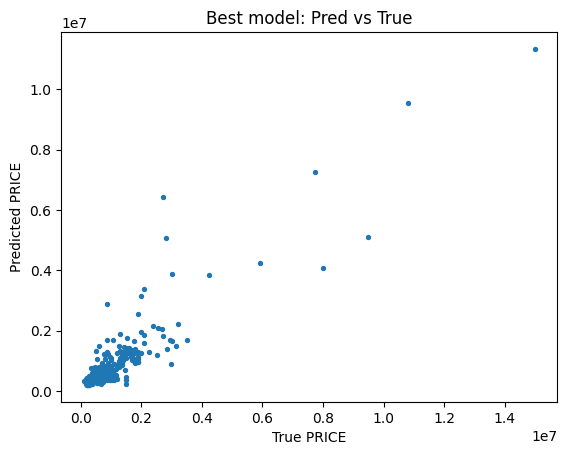

In [86]:
error_analysis_plot(y_val_raw, predict_from_log(best_pipe, X_val), "Best model: Pred vs True")

In [87]:
best_pipe.named_steps["model"]


HistGradientBoostingRegressor(random_state=42)

In [88]:
y_pred_val_raw = predict_from_log(pipe, X_val)
metrics = evaluate_regression(y_val_raw, y_pred_val_raw, prefix=f"{name}_")
result = {
        "model": name,
        "MAE": metrics[f"{name}_MAE"],
        "RMSLE": metrics[f"{name}_RMSLE"],
        "R2": metrics[f"{name}_R2"],
    }
print(result)


{'model': 'RandomForest', 'MAE': 269714.57295738143, 'RMSLE': np.float64(0.43722501630419247), 'R2': 0.849601185966923}


In [89]:
from sklearn.metrics import mean_absolute_error, make_scorer

def raw_mae_from_log_predictions(y_true, y_pred_log):
  y_pred_raw = np.expm1(y_pred_log)
  return mean_absolute_error(y_true=y_true, y_pred=y_pred_raw)

raw_mae_scorer = make_scorer(raw_mae_from_log_predictions, greater_is_better=False)

In [90]:
from sklearn.inspection import permutation_importance
import pandas as pd

r = permutation_importance(best_pipe,
                           X_val,
                           y_val_raw,
                           scoring=raw_mae_scorer,
                           n_repeats=10,
                           random_state=RANDON_SEED)

im_df = pd.DataFrame({
    "feature": X_val.columns,
    "importance": r.importances_mean
}).sort_values("importance", ascending=False)
im_df

,feature,importance
3,BATH,165221.562500
7,LATITUDE,106931.943908
4,PROPERTYSQFT,59167.568592
8,LONGITUDE,50308.682951
12,BEDS_X_SQFT,42693.377353
1,TYPE,32938.577904
2,BEDS,8658.656418
10,BED_TO_BATH_RATIO,8488.872045
5,ADMINISTRATIVE_AREA_LEVEL_2,0.000000
11,SQFT_SIZE_BINS,0.000000


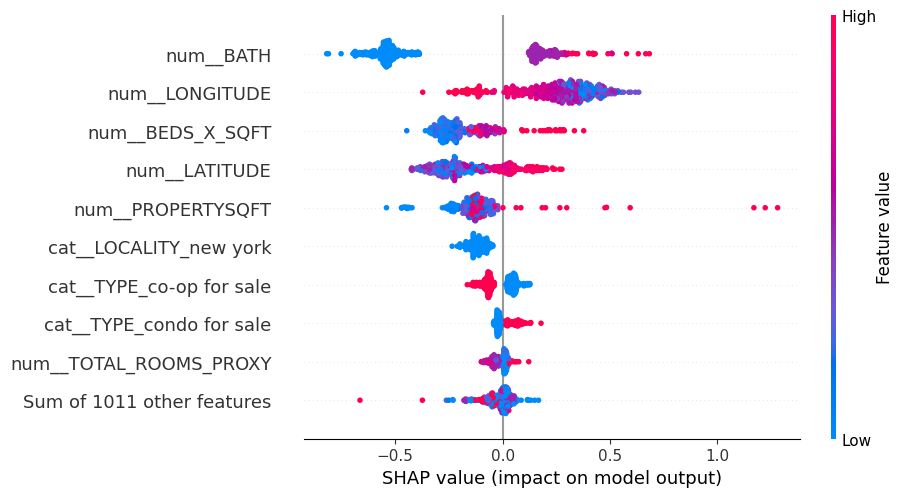

In [91]:
import shap
import pandas as pd

pre = best_pipe.named_steps["preprocessor"]
model = best_pipe.named_steps["model"]

X_val_t = pre.transform(X_val)
names = pre.get_feature_names_out()

if hasattr(X_val_t, "toarray"):
    X_val_t = X_val_t.toarray()

X_val_t = pd.DataFrame(X_val_t, columns=names)

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_val_t)

shap.plots.beeswarm(shap_values)


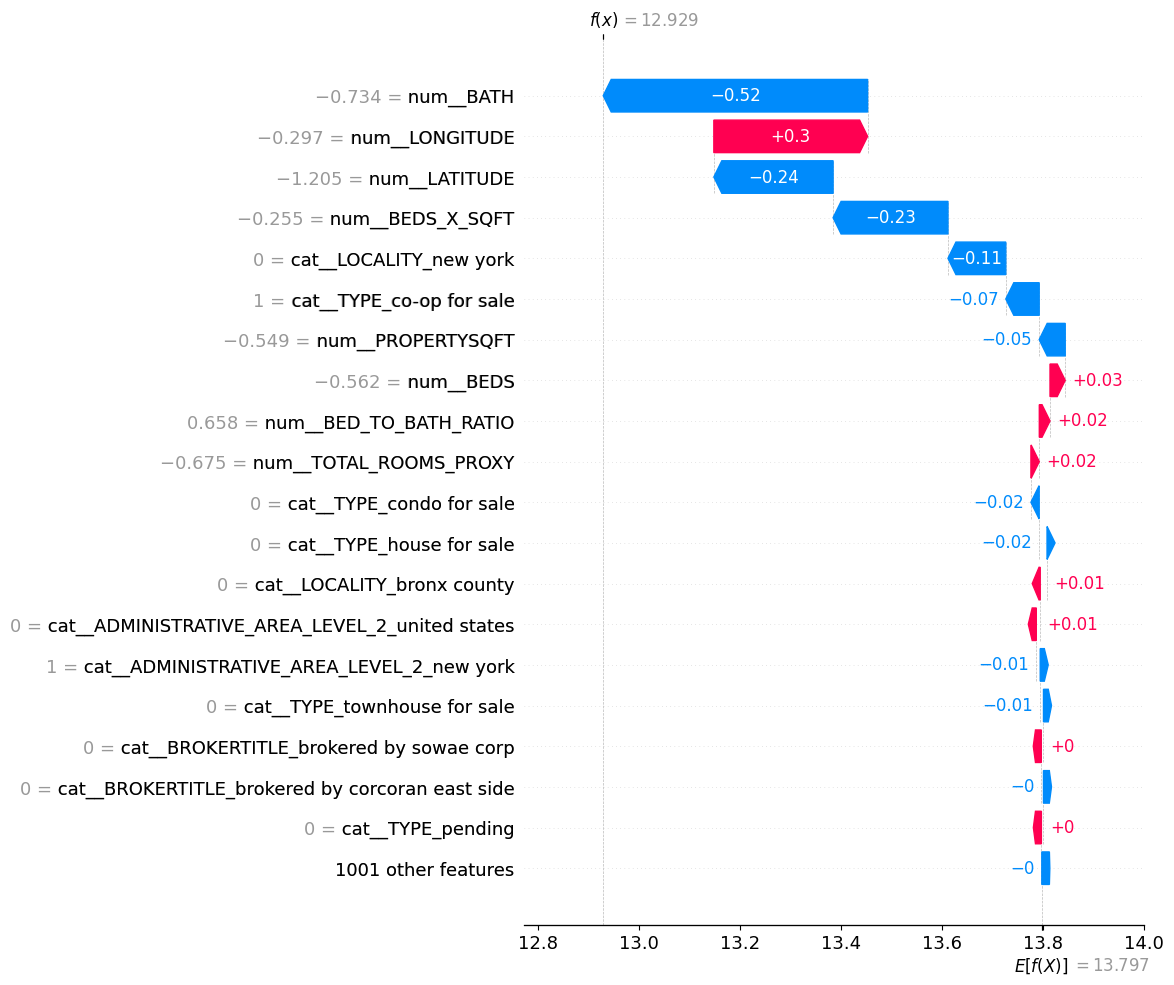

Baseline: 13.797331553207183
Prediction: 12.928819542835535
Baseline + SHAP sum: 12.928819542835528


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but HistGradientBoostingRegressor was fitted without feature names
  warnings.warn(


In [92]:
i = 0   # any row you want to explain
shap.plots.waterfall(shap_values[i], max_display=20)
row = X_val_t.iloc[[i]]

pred = model.predict(row)[0]
base = shap_values.base_values[i]
contrib_sum = shap_values.values[i].sum()

print("Baseline:", base)
print("Prediction:", pred)
print("Baseline + SHAP sum:", base + contrib_sum)